# Data mining

In [1]:
import pandas as pd

df = pd.read_csv("new_wafer_data.csv")
df

,Unnamed: 0,LOT,WAFER,OBSERVATION,T0001,T0002,T0003,T0004,T0005,T0006,...,T2731,T2732,T2733,T2734,T2735,T2736,T2737,T2738,T2739,T2740
0,1,LOT1,1,14.5480,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
1,2,LOT1,2,14.6524,0,0,0,1,0,0,...,1,0,0,0,1,0,0,0,0,1
2,3,LOT1,3,14.4436,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
3,4,LOT1,4,15.0736,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
4,5,LOT1,5,14.9692,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,241,LOT10,20,18.1084,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
241,242,LOT10,21,18.9976,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
242,243,LOT10,22,19.6240,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
243,244,LOT10,23,16.4848,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [2]:
df = df.drop(columns=["Unnamed: 0"])
# 檢查缺失值
print(df.isnull().sum())

LOT            0
WAFER          0
OBSERVATION    0
T0001          0
T0002          0
              ..
T2736          0
T2737          0
T2738          0
T2739          0
T2740          0
Length: 2743, dtype: int64


In [3]:
# 基本描述統計
print(df.describe())

            WAFER  OBSERVATION       T0001       T0002       T0003  \
count  245.000000   245.000000  245.000000  245.000000  245.000000   
mean    12.759184    16.292487    0.048980    0.008163    0.493878   
std      7.096753     1.834524    0.216267    0.090165    0.500986   
min      1.000000    11.200000    0.000000    0.000000    0.000000   
25%      7.000000    14.706400    0.000000    0.000000    0.000000   
50%     13.000000    15.962800    0.000000    0.000000    0.000000   
75%     19.000000    17.687200    0.000000    0.000000    1.000000   
max     25.000000    22.136800    1.000000    1.000000    1.000000   

            T0004       T0005       T0006       T0007       T0008  ...  \
count  245.000000  245.000000  245.000000  245.000000  245.000000  ...   
mean     0.200000    0.306122    0.306122    0.102041    0.097959  ...   
std      0.400819    0.461825    0.461825    0.303322    0.297868  ...   
min      0.000000    0.000000    0.000000    0.000000    0.000000  ...   

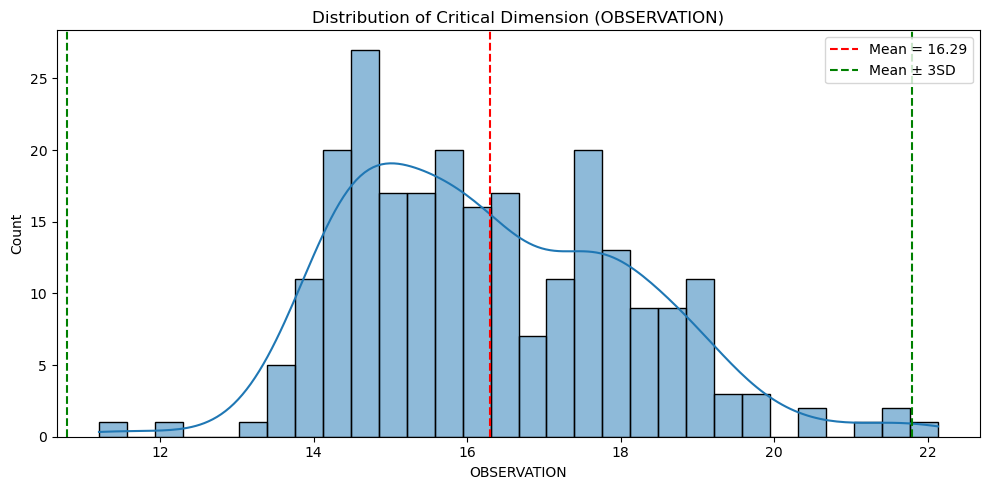

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 製程總體描述統計
mean_obs = df['OBSERVATION'].mean()
std_obs = df['OBSERVATION'].std()
min_obs = df['OBSERVATION'].min()
max_obs = df['OBSERVATION'].max()
iqr_obs = df['OBSERVATION'].quantile(0.75) - df['OBSERVATION'].quantile(0.25)

# 2. 繪製整體觀測值分布
plt.figure(figsize=(10, 5))
sns.histplot(df['OBSERVATION'], bins=30, kde=True)
plt.axvline(mean_obs, color='red', linestyle='--', label=f'Mean = {mean_obs:.2f}')
plt.axvline(mean_obs + 3*std_obs, color='green', linestyle='--', label='Mean ± 3SD')
plt.axvline(mean_obs - 3*std_obs, color='green', linestyle='--')
plt.title('Distribution of Critical Dimension (OBSERVATION)')
plt.xlabel('OBSERVATION')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
grouped_by_log = df.groupby("LOT")["OBSERVATION"]
# 計算每批平均值 (X-bar)
x_bar = grouped_by_log.mean()
x_bar

LOT
LOT1     14.815150
LOT10    19.201750
LOT2     15.124432
LOT3     15.030550
LOT4     17.131360
LOT5     17.835232
LOT6     15.208240
LOT7     14.396080
LOT8     17.851861
LOT9     16.461760
Name: OBSERVATION, dtype: float64

In [6]:
# 每批樣本數 (n)
n = grouped_by_log.count()
n

LOT
LOT1     24
LOT10    24
LOT2     25
LOT3     24
LOT4     25
LOT5     25
LOT6     25
LOT7     25
LOT8     23
LOT9     25
Name: OBSERVATION, dtype: int64

In [7]:
# 批內樣本數幾乎都接近，取平均值
avg_n = int(round(n.mean()))
avg_n

24

In [8]:
S = df.groupby("LOT")["OBSERVATION"].std()
S

LOT
LOT1     0.604192
LOT10    1.514184
LOT2     1.002548
LOT3     0.770702
LOT4     0.886855
LOT5     0.984173
LOT6     0.973488
LOT7     0.648230
LOT8     1.004285
LOT9     1.357772
Name: OBSERVATION, dtype: float64

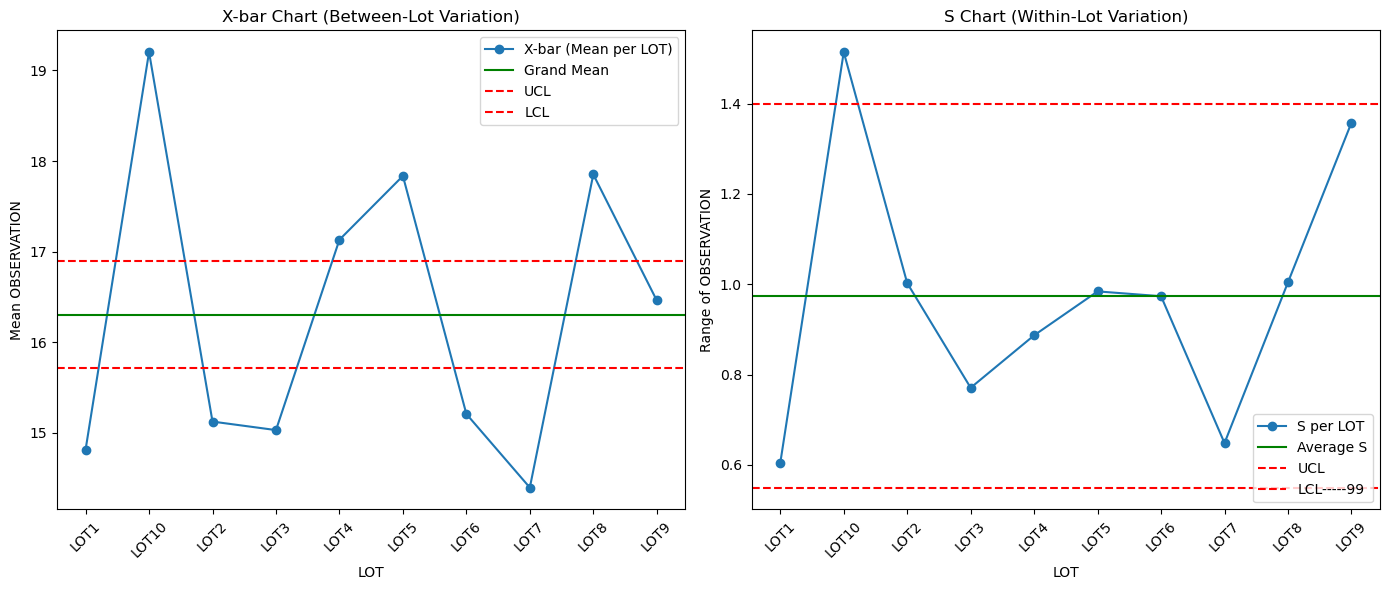

In [10]:
import numpy as np


S_bar = S.mean()
grand_mean = x_bar.mean()   
# c4(n=25) = 0.9896
c4 = 0.9896


# 繪製控制圖
plt.figure(figsize=(14,6))

# X-bar chart
plt.subplot(1,2,1)
plt.plot(x_bar.index, x_bar.values, marker='o', linestyle='-', label='X-bar (Mean per LOT)')
plt.axhline(grand_mean, color='green', label='Grand Mean')
plt.axhline(grand_mean + 3*S_bar/(c4*5), color='red', linestyle='--', label='UCL')
plt.axhline(grand_mean - 3*S_bar/(c4*5), color='red', linestyle='--', label='LCL')
plt.title('X-bar Chart (Between-Lot Variation)')
plt.xlabel('LOT')
plt.ylabel('Mean OBSERVATION')
plt.xticks(rotation=45)
plt.legend()

# R chart
plt.subplot(1,2,2)
plt.plot(S.index, S.values, marker='o', linestyle='-', label='S per LOT')
plt.axhline(S_bar, color='green', label='Average S')
plt.axhline(S_bar + 3*S_bar*np.sqrt(1-c4**2)/c4, color='red', linestyle='--', label='UCL')
plt.axhline(S_bar - 3*S_bar*np.sqrt(1-c4**2)/c4, color='red', linestyle='--', label='LCL-----99')
plt.title('S Chart (Within-Lot Variation)')
plt.xlabel('LOT')
plt.ylabel('Range of OBSERVATION')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# 管制圖

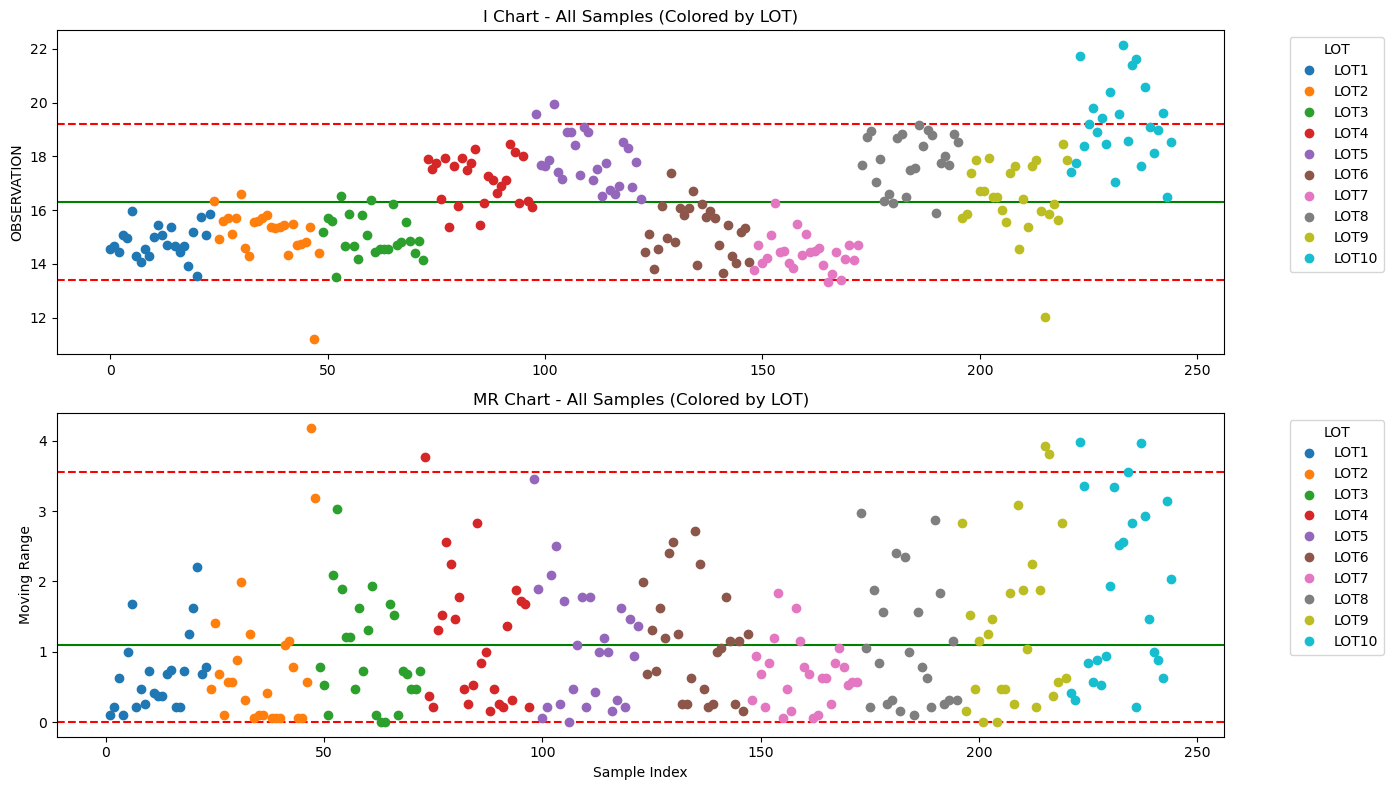

In [12]:
import matplotlib.pyplot as plt
import numpy as np


# 準備基礎統計
i_values = df['OBSERVATION'].values
i_mean = np.mean(i_values)

# 計算 MR
mr_values = [abs(i_values[i] - i_values[i - 1]) for i in range(1, len(i_values))]
mr_bar = np.mean(mr_values)

# 控制線參數
d2 = 1.128
ucl_i = i_mean + 3 * (mr_bar / d2)
lcl_i = i_mean - 3 * (mr_bar / d2)
ucl_mr = mr_bar * 3.267
lcl_mr = 0

# 設定 LOT 對應顏色
unique_lots = df['LOT'].unique()
color_map = {lot: plt.cm.tab10(i % 10) for i, lot in enumerate(unique_lots)}

# 畫圖
fig, axs = plt.subplots(2, 1, figsize=(14, 8))

# I Chart
axs[0].set_title('I Chart - All Samples (Colored by LOT)')
axs[0].set_ylabel('OBSERVATION')
axs[0].axhline(i_mean, color='green', label='Mean')
axs[0].axhline(ucl_i, color='red', linestyle='--', label='UCL')
axs[0].axhline(lcl_i, color='red', linestyle='--', label='LCL')

# MR Chart
axs[1].set_title('MR Chart - All Samples (Colored by LOT)')
axs[1].set_ylabel('Moving Range')
axs[1].set_xlabel('Sample Index')
axs[1].axhline(mr_bar, color='green', label='Average MR')
axs[1].axhline(ucl_mr, color='red', linestyle='--', label='UCL')
axs[1].axhline(lcl_mr, color='red', linestyle='--', label='LCL')

# 畫每一點，根據 LOT 上色
for i in range(len(i_values)):
    lot = df.iloc[i]['LOT']
    color = color_map[lot]
    axs[0].plot(i, i_values[i], marker='o', color=color)
    if i > 0:
        axs[1].plot(i, mr_values[i-1], marker='o', color=color)

# 圖例只顯示一次每個 LOT
handles = [plt.Line2D([0], [0], marker='o', color=color_map[lot], label=lot, linestyle='') for lot in unique_lots]
axs[0].legend(handles=handles, title="LOT", bbox_to_anchor=(1.05, 1), loc='upper left')
axs[1].legend(handles=handles, title="LOT", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


## drop outliers

In [13]:
df[i_values < lcl_i]

,LOT,WAFER,OBSERVATION,T0001,T0002,T0003,T0004,T0005,T0006,T0007,...,T2731,T2732,T2733,T2734,T2735,T2736,T2737,T2738,T2739,T2740
47,LOT2,24,11.2000,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,0
165,LOT7,18,13.3456,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
168,LOT7,21,13.3960,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
215,LOT9,20,12.0388,0,0,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1


In [15]:
# 先確認 index 是 0-based 還是實際的資料索引，如果是 0-based（通常是）
df_drop = df.drop(index=[47, 215])
df_drop

,LOT,WAFER,OBSERVATION,T0001,T0002,T0003,T0004,T0005,T0006,T0007,...,T2731,T2732,T2733,T2734,T2735,T2736,T2737,T2738,T2739,T2740
0,LOT1,1,14.5480,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
1,LOT1,2,14.6524,0,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,1
2,LOT1,3,14.4436,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,LOT1,4,15.0736,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
4,LOT1,5,14.9692,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,LOT10,20,18.1084,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
241,LOT10,21,18.9976,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
242,LOT10,22,19.6240,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
243,LOT10,23,16.4848,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


## 不良率

In [16]:
17/245

0.06938775510204082

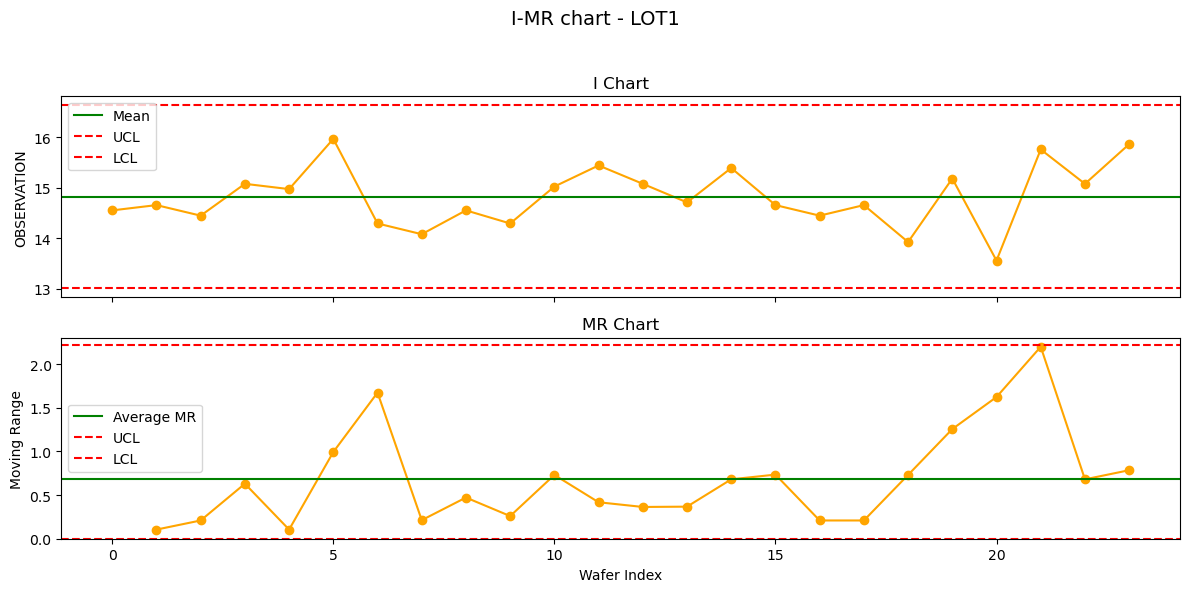

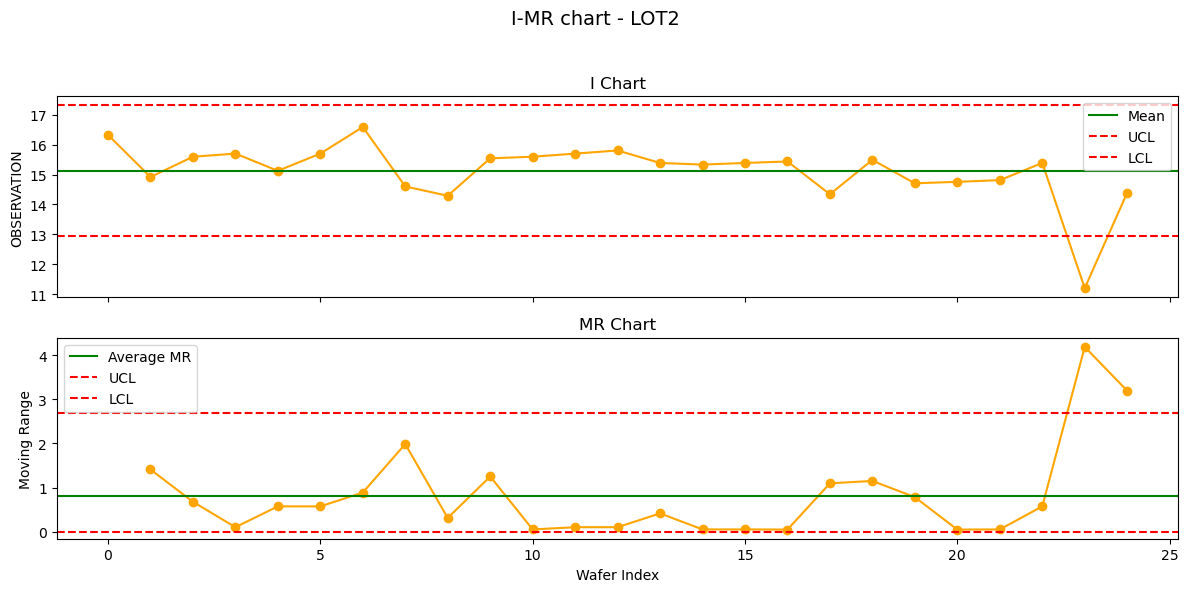

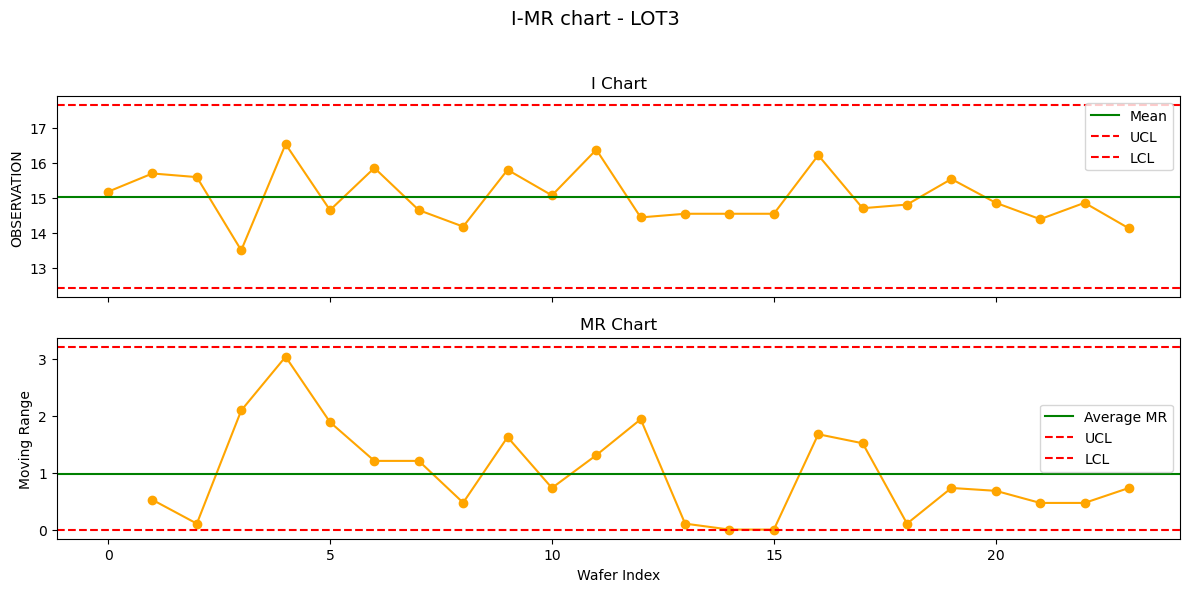

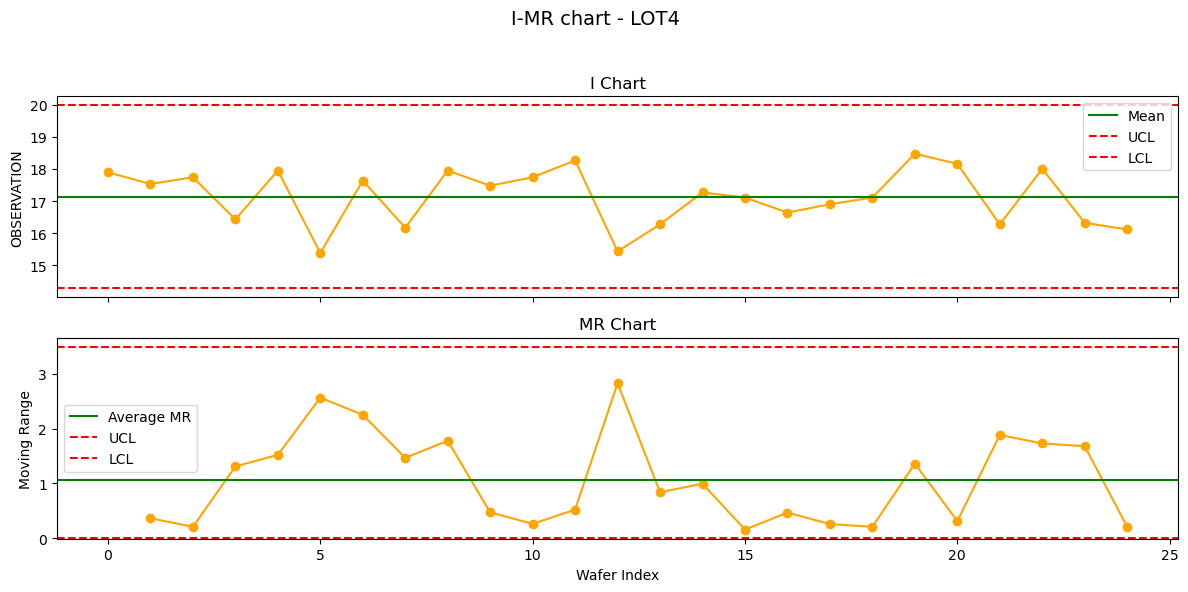

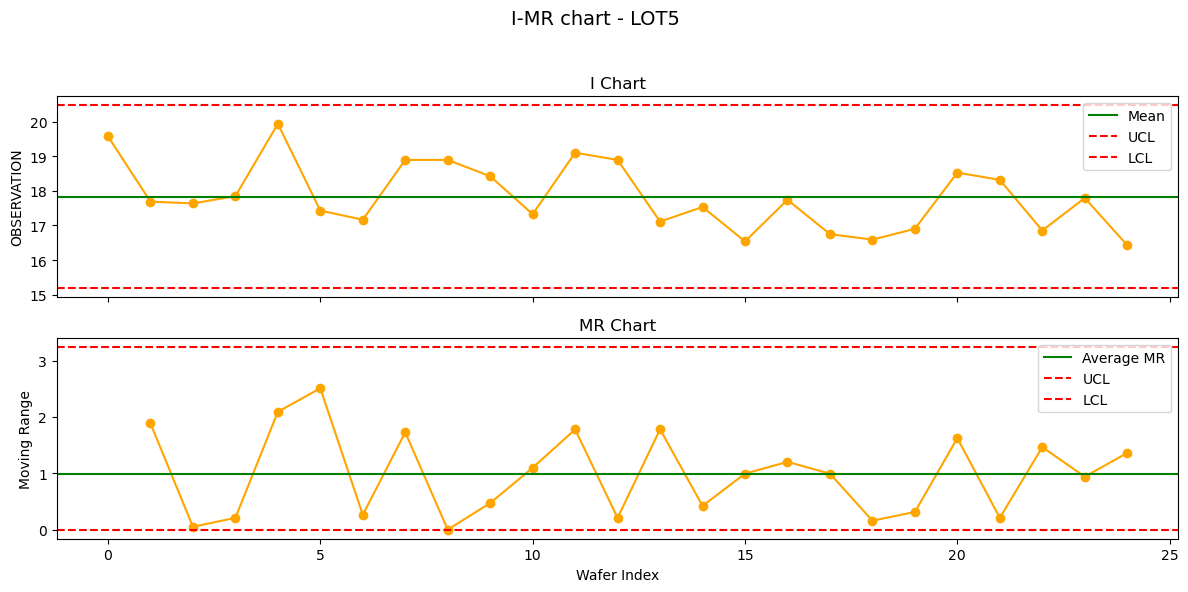

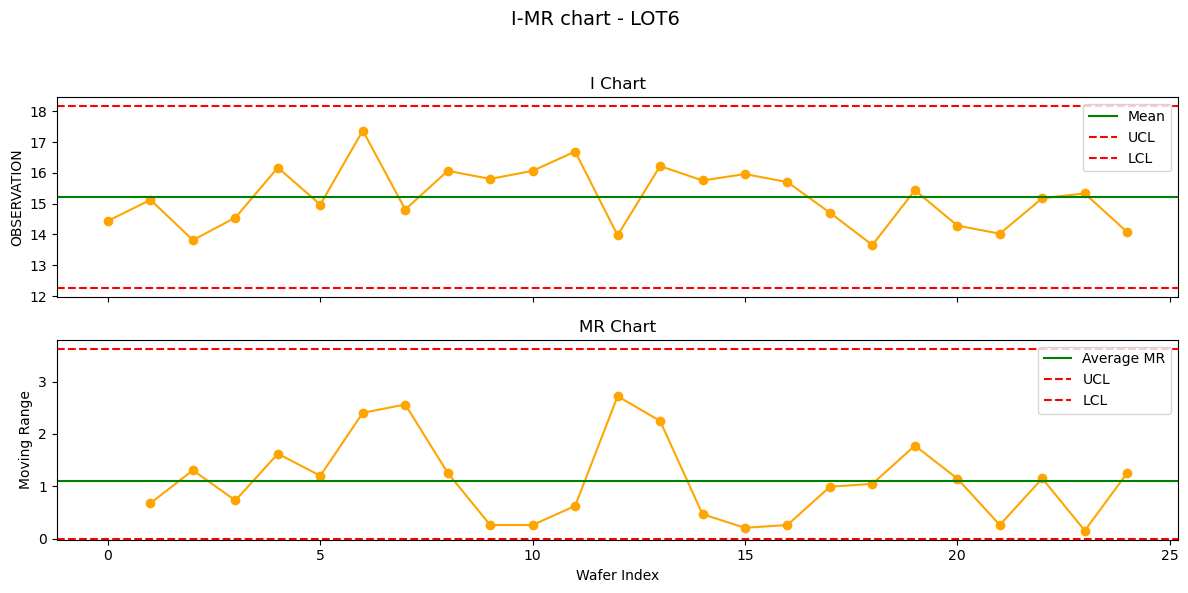

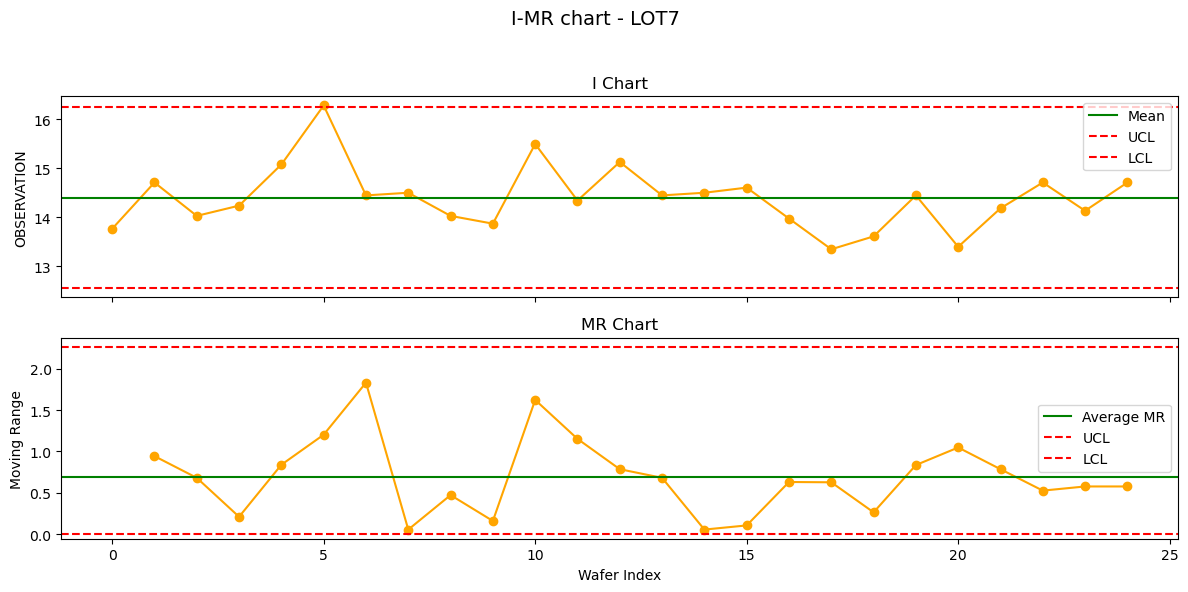

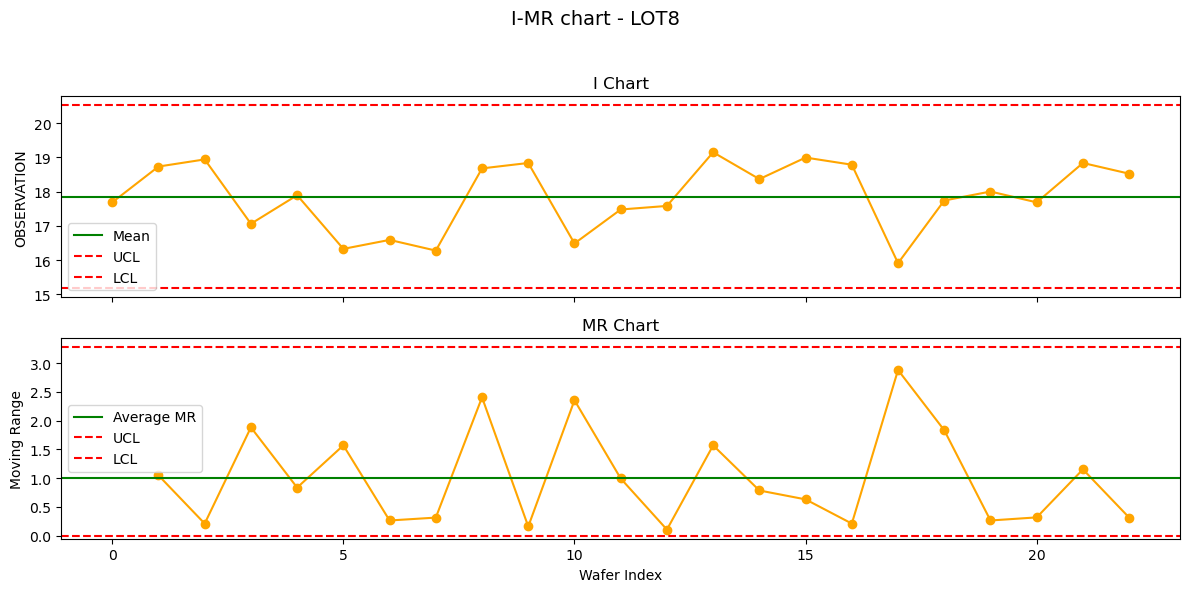

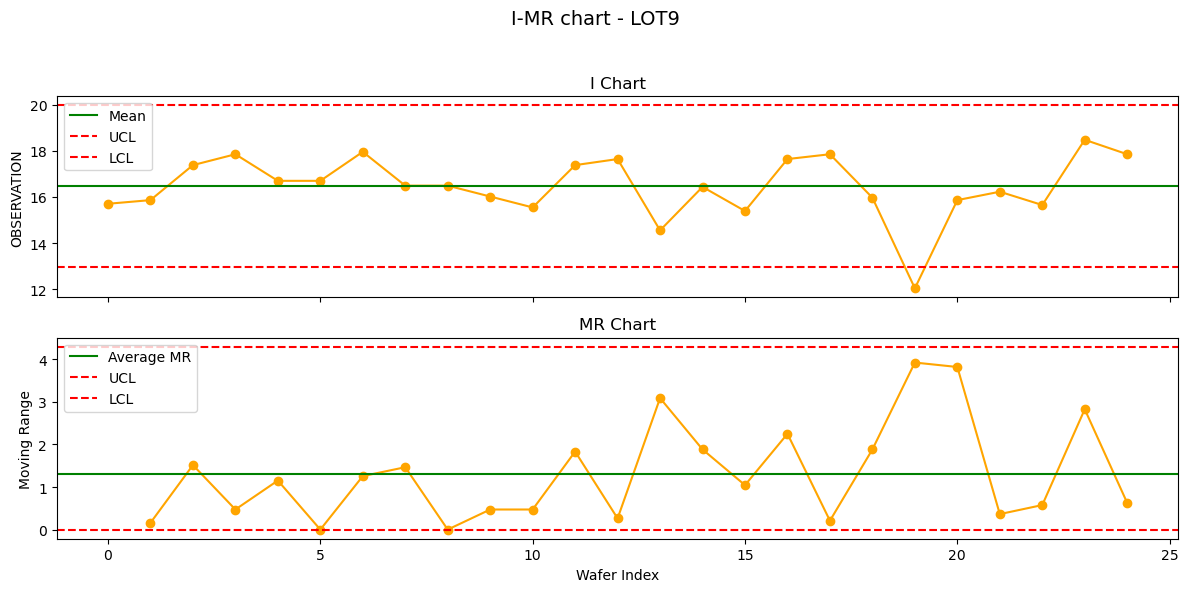

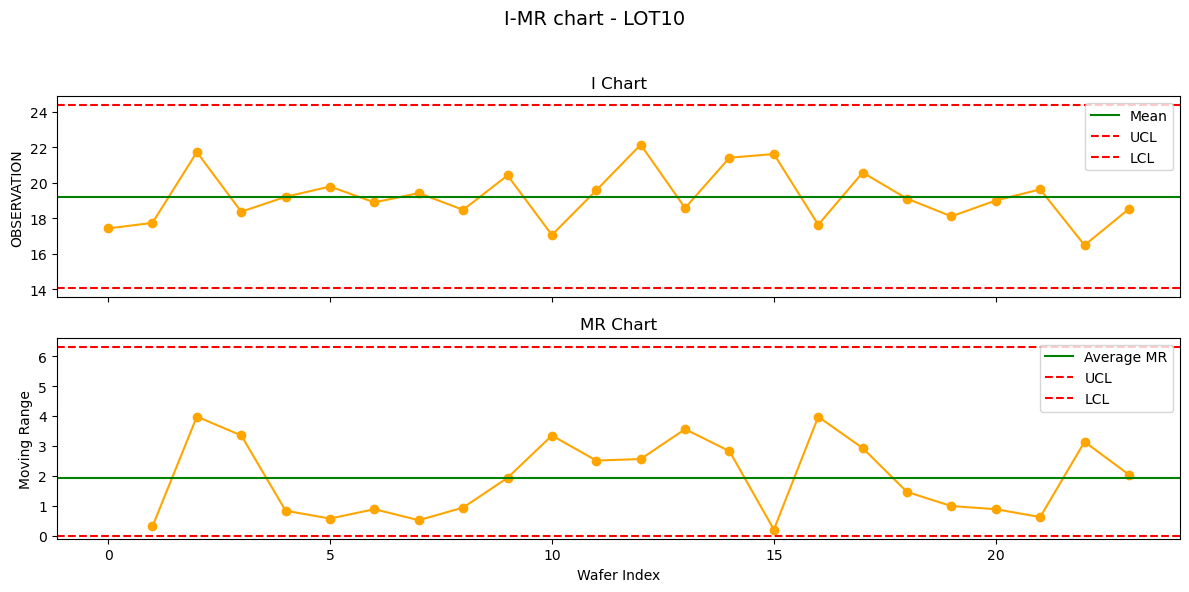

In [18]:
mr_bar_list = []

# 抓取所有 LOT 名單
unique_lots = df['LOT'].unique()

# 繪製每個 LOT 對應的 I-MR 控制圖
def plot_all_imr_charts(data, lots):
    for lot_id in lots:
        lot_df = data[data['LOT'] == lot_id]
        i_values = lot_df['OBSERVATION'].values
        i_index = range(len(i_values))
        i_mean = np.mean(i_values)

        # 移動範圍計算
        mr_values = [abs(i_values[i] - i_values[i-1]) for i in range(1, len(i_values))]
        mr_bar = np.mean(mr_values)
        mr_bar_list.append(mr_bar)
        # 控制線設定 (for n=2: d2 ≈ 1.128, D4 ≈ 3.267, D3 = 0)
        i_ucl = i_mean + 3 * (mr_bar / 1.128)
        i_lcl = i_mean - 3 * (mr_bar / 1.128)
        mr_ucl = mr_bar * 3.267
        mr_lcl = 0

        fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        fig.suptitle(f'I-MR chart - {lot_id}', fontsize=14)

        # I Chart
        axs[0].plot(i_index, i_values, marker='o', linestyle='-', color='orange')
        axs[0].axhline(i_mean, color='green', label='Mean')
        axs[0].axhline(i_ucl, color='red', linestyle='--', label='UCL')
        axs[0].axhline(i_lcl, color='red', linestyle='--', label='LCL')
        axs[0].set_ylabel('OBSERVATION')
        axs[0].set_title('I Chart')
        axs[0].legend()

        # MR Chart
        axs[1].plot(i_index[1:], mr_values, marker='o', linestyle='-', color='orange')
        axs[1].axhline(mr_bar, color='green', label='Average MR')
        axs[1].axhline(mr_ucl, color='red', linestyle='--', label='UCL')
        axs[1].axhline(mr_lcl, color='red', linestyle='--', label='LCL')
        axs[1].set_ylabel('Moving Range')
        axs[1].set_xlabel('Wafer Index')
        axs[1].set_title('MR Chart')
        axs[1].legend()

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

# 限制 LOT1~LOT10 繪製
plot_all_imr_charts(df, [f'LOT{i}' for i in range(1, 11)])


# 檢定

In [19]:
import pandas as pd
from scipy.stats import levene

groups = df['LOT'].unique()

# 取得每組的 observation
data_groups = [df.loc[df['LOT'] == g, 'OBSERVATION'] for g in groups]

# 做 levene 檢定
stat, pvalue = levene(*data_groups)

print(f"Levene 檢定統計量: {stat:.4f}")
print(f"p-value: {pvalue:.4f}")

if pvalue > 0.05:
    print("Fail to reject H0: 各組變異數相等 (同質變異數)")
else:
    print("Reject H0: 各組變異數不相等 (異質變異數)")


Levene 檢定統計量: 2.9195
p-value: 0.0027
Reject H0: 各組變異數不相等 (異質變異數)


In [20]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


# 確認分組欄位名稱，這裡先用 'GROUP' 當例子
print(df['LOT'].unique())

# 建立模型（依分組 GROUP 比較 OBSERVATION）
model = ols('OBSERVATION ~ LOT', data=df).fit()

# 做 Welch ANOVA (type=2 指定類型)
anova_results = anova_lm(model, typ=2, robust='hc3')  # robust='hc3' 做異質變異數調整 (Welch)

print(anova_results)


['LOT1' 'LOT2' 'LOT3' 'LOT4' 'LOT5' 'LOT6' 'LOT7' 'LOT8' 'LOT9' 'LOT10']
              sum_sq     df          F        PR(>F)
LOT       597.942148    9.0  64.972882  8.759712e-59
Residual  240.299234  235.0        NaN           NaN


In [21]:
import pingouin as pg


# 做 Welch ANOVA
welch = pg.welch_anova(dv='OBSERVATION', between='LOT', data=df)

print(welch)


  Source  ddof1      ddof2          F         p-unc       np2
0    LOT      9  95.321796  64.170005  1.583480e-36  0.707372


In [22]:
import pandas as pd
import pingouin as pg



results = pg.pairwise_gameshowell(dv='OBSERVATION', between='LOT', data=df)

print(results)


        A      B    mean(A)    mean(B)      diff        se          T  \
0    LOT1  LOT10  14.815150  19.201750 -4.386600  0.332779 -13.181727   
1    LOT1   LOT2  14.815150  15.124432 -0.309282  0.235403  -1.313842   
2    LOT1   LOT3  14.815150  15.030550 -0.215400  0.199899  -1.077545   
3    LOT1   LOT4  14.815150  17.131360 -2.316210  0.216034 -10.721496   
4    LOT1   LOT5  14.815150  17.835232 -3.020082  0.232280 -13.001880   
5    LOT1   LOT6  14.815150  15.208240 -0.393090  0.230472  -1.705584   
6    LOT1   LOT7  14.815150  14.396080  0.419070  0.178937   2.341998   
7    LOT1   LOT8  14.815150  17.851861 -3.036711  0.243027 -12.495374   
8    LOT1   LOT9  14.815150  16.461760 -1.646610  0.298248  -5.520935   
9   LOT10   LOT2  19.201750  15.124432  4.077318  0.368423  11.066945   
10  LOT10   LOT3  19.201750  15.030550  4.171200  0.346815  12.027162   
11  LOT10   LOT4  19.201750  17.131360  2.070390  0.356359   5.809840   
12  LOT10   LOT5  19.201750  17.835232  1.366518  0

In [23]:
# 取得所有 LOT 名稱（排序）
lots = sorted(df['LOT'].unique())

pval_matrix = pd.DataFrame(np.ones((len(lots), len(lots))), index=lots, columns=lots)

for _, row in results.iterrows():
    A = row['A']
    B = row['B']
    p = row['pval']
    pval_matrix.loc[A, B] = p
    pval_matrix.loc[B, A] = p  # 對稱

# 同組比較設為 0 或 1（通常用 1 表示無差異）
np.fill_diagonal(pval_matrix.values, 1)

print(pval_matrix)

               LOT1         LOT10          LOT2          LOT3          LOT4  \
LOT1   1.000000e+00  2.064460e-12  9.444373e-01  9.844646e-01  5.198175e-12   
LOT10  2.064460e-12  1.000000e+00  4.679146e-12  3.433143e-12  4.655718e-05   
LOT2   9.444373e-01  4.679146e-12  1.000000e+00  9.999972e-01  6.090989e-08   
LOT3   9.844646e-01  3.433143e-12  9.999972e-01  1.000000e+00  6.553840e-10   
LOT4   5.198175e-12  4.655718e-05  6.090989e-08  6.553840e-10  1.000000e+00   
LOT5   2.531308e-14  1.901164e-02  3.603107e-11  6.704637e-13  2.210890e-01   
LOT6   7.858825e-01  8.544054e-12  9.999996e-01  9.993131e-01  1.159254e-07   
LOT7   3.827559e-01  1.555422e-13  9.969488e-02  8.417583e-02  1.199041e-14   
LOT8   5.617729e-13  2.527925e-02  1.305182e-10  6.449841e-12  2.366469e-01   
LOT9   1.479115e-04  1.270921e-06  9.081727e-03  1.865417e-03  5.612501e-01   

               LOT5          LOT6          LOT7          LOT8      LOT9  
LOT1   2.531308e-14  7.858825e-01  3.827559e-01  5.61772

C:\Users\jason\AppData\Local\Temp\ipykernel_50396\2709651805.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="LOT_GROUP", y="OBSERVATION", palette="Set2")


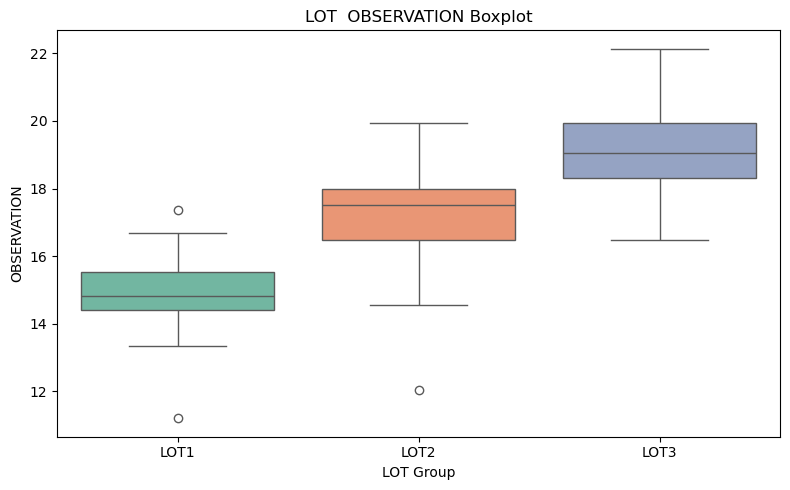

In [28]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns



# 把 LOT 轉成數字部分
df["LOT_NUM"] = df["LOT"].astype(str).str.extract(r"(\d+)").astype(int)

# 定義三群
def lot_group(num):
    if num in [1, 2, 3, 6, 7]:
        return "LOT1"
    elif num in [4, 5, 8, 9]:
        return "LOT2"
    else:
        return "LOT3"

df["LOT_GROUP"] = df["LOT_NUM"].apply(lot_group)

# 繪製 boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="LOT_GROUP", y="OBSERVATION", palette="Set2")
plt.xlabel("LOT Group")
plt.ylabel("OBSERVATION")
plt.title("LOT  OBSERVATION Boxplot")
plt.tight_layout()
plt.show()


In [29]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.ols("OBSERVATION ~ C(LOT)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


              sum_sq     df          F        PR(>F)
C(LOT)    580.877751    9.0  63.118651  9.537691e-58
Residual  240.299234  235.0        NaN           NaN


In [30]:
between_var = anova_table.loc['C(LOT)', 'sum_sq']
within_var = anova_table.loc['Residual', 'sum_sq']
total_var = between_var + within_var

print(f"組間變異比例: {between_var / total_var:.3f}")
print(f"組內變異比例: {within_var / total_var:.3f}")

組間變異比例: 0.707
組內變異比例: 0.293


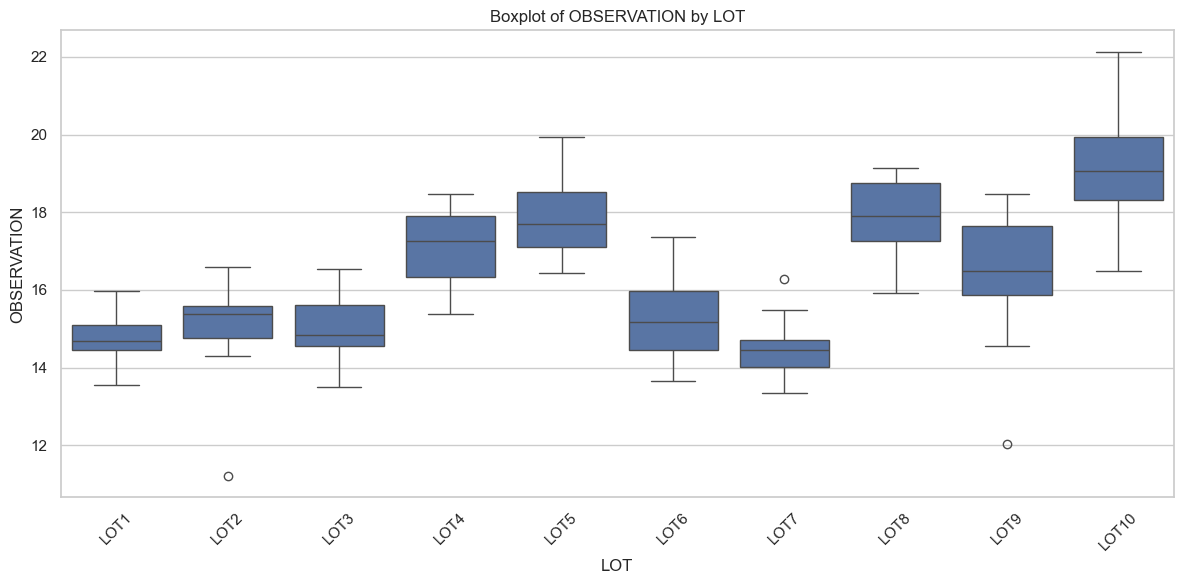

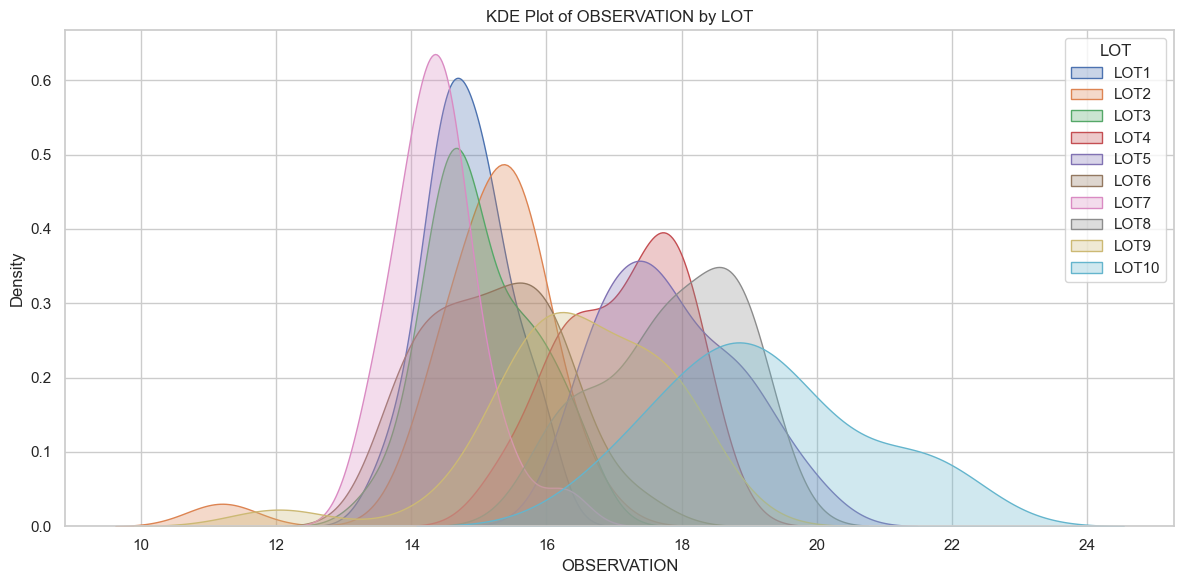

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# 設定畫圖風格
sns.set(style="whitegrid")

# Boxplot: 每個 LOT 的 OBSERVATION 分布
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="LOT", y="OBSERVATION")
plt.title("Boxplot of OBSERVATION by LOT")
plt.ylabel("OBSERVATION")
plt.xlabel("LOT")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# KDE Plot: 每個 LOT 的密度曲線
plt.figure(figsize=(12, 6))
for lot in df["LOT"].unique():
    sns.kdeplot(df[df["LOT"] == lot]["OBSERVATION"], label=lot, fill=True, alpha=0.3)
plt.title("KDE Plot of OBSERVATION by LOT")
plt.xlabel("OBSERVATION")
plt.ylabel("Density")
plt.legend(title="LOT")
plt.tight_layout()
plt.show()


# 網路

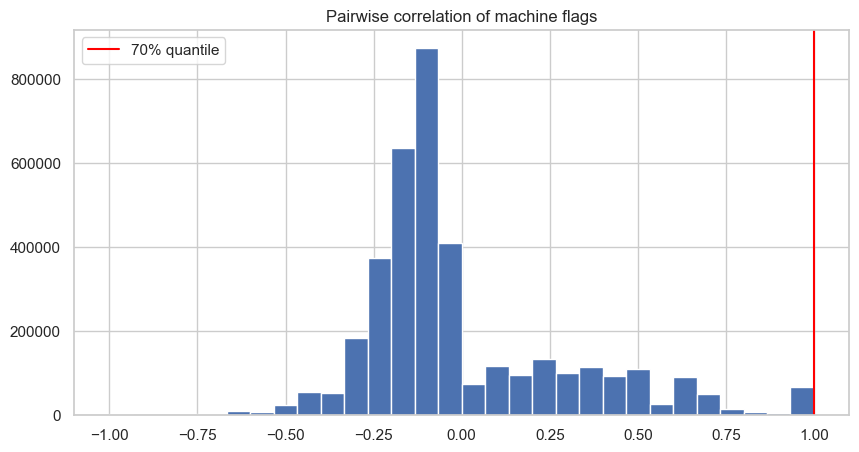

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

# 機台欄位
route_cols = [c for c in df_drop.columns if c.startswith("T")]
T_corr = df[route_cols].corr()

# 提取上三角非對角元素
tmp_p = len(route_cols)
upper_cor_values = [T_corr.values[i, j] for i, j in itertools.combinations(range(tmp_p), 2)]
upper_cor_values = np.array(upper_cor_values)  # 轉成 numpy array

# 取 70% 分位數作為 threshold
upper_cor_values_clean = upper_cor_values[~np.isnan(upper_cor_values)]
tmp_quan = 1

plt.figure(figsize=(10, 5))
plt.hist(upper_cor_values_clean, bins=30)
plt.axvline(x=tmp_quan, color='red', label='70% quantile')
plt.title("Pairwise correlation of machine flags")
plt.legend()
plt.show()


In [35]:
Adjacency_matrix = (T_corr >= tmp_quan).astype(int)
np.fill_diagonal(Adjacency_matrix.values, 0)

In [36]:
import networkx as nx

def network_construct(adjacency_matrix):
    node_names = adjacency_matrix.index.values
    rows, cols = np.where(adjacency_matrix.values == 1)
    edges = [(node_names[i], node_names[j]) for i, j in zip(rows, cols) if i < j]
    
    gr = nx.Graph()
    gr.add_nodes_from(node_names)
    gr.add_edges_from(edges)
    return gr

tmp_net = network_construct(Adjacency_matrix)

In [37]:
print(tmp_net.number_of_edges())
print(tmp_net.number_of_nodes())


60506
2740


In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
from pyvis.network import Network

# 預先先用 spring layout 給個初始合理位置
pos = nx.spring_layout(tmp_net, iterations=50, seed=42)

net = Network(notebook=True, height="750px", width="100%", bgcolor="#222222", font_color="white")

for node, (x, y) in pos.items():
    net.add_node(node, label='', title=node, x=x*1000, y=y*1000)

for source, target in tmp_net.edges():
    net.add_edge(source, target)

# 讓瀏覽器端 physics 開啟，但只做微調
net.set_options("""
var options = {
  "physics": {
    "enabled": true,
    "stabilization": {
      "enabled": true,
      "iterations": 100,
      "fit": true
    },
    "barnesHut": {
      "gravitationalConstant": -3000,
      "centralGravity": 0.3,
      "springLength": 100,
      "springConstant": 0.01,
      "damping": 0.9
    }
  }
}
""")

net.show("network.html")


# TWOHIT挑選為基底暴力挑選機台建模

In [38]:
m = smf.ols("OBSERVATION ~ T0404 + T1370  + T0447 + T1202  + T1334 + T2627 ", data=df_drop).fit()
print(m.summary())

                            OLS Regression Results                            
Dep. Variable:            OBSERVATION   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     137.6
Date:                Mon, 09 Jun 2025   Prob (F-statistic):           3.74e-74
Time:                        13:57:33   Log-Likelihood:                -303.29
No. Observations:                 243   AIC:                             620.6
Df Residuals:                     236   BIC:                             645.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     14.9629      0.084    177.280      0.0

In [39]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

# Breusch-Pagan test
bp_test = het_breuschpagan(m.resid, m.model.exog)
bp_labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print("Breusch-Pagan test:")
print(dict(zip(bp_labels, bp_test)))

# White test
white_test = het_white(m.resid, m.model.exog)
white_labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print("\nWhite test:")
print(dict(zip(white_labels, white_test)))

Breusch-Pagan test:
{'LM Statistic': 23.320511635224676, 'LM-Test p-value': 0.0006959392869210012, 'F-Statistic': 4.175507984291408, 'F-Test p-value': 0.0005200520410744025}

White test:
{'LM Statistic': 34.2102128762142, 'LM-Test p-value': 0.0006249208666884358, 'F-Statistic': 3.140458907625408, 'F-Test p-value': 0.0003695403107699948}


In [45]:
# One-Hot Encoding
df_onehot_drop = pd.get_dummies(df_drop, columns=['LOT'], prefix='LOT')

# 強制將所有 One-Hot 欄位轉成 0/1 (int)
lot_cols = [col for col in df_onehot_drop.columns if col.startswith('LOT_')]
df_onehot_drop[lot_cols] = df_onehot_drop[lot_cols].astype(int)

# 確認轉換結果
print(df_onehot_drop.head())
print("One-Hot 產生後的新欄位（已轉換為整數 0/1）：", lot_cols)

   WAFER  OBSERVATION  T0001  T0002  T0003  T0004  T0005  T0006  T0007  T0008  \
0      1      14.5480      0      0      0      1      0      0      0      0   
1      2      14.6524      0      0      0      1      0      0      0      0   
2      3      14.4436      0      0      0      1      0      0      0      0   
3      4      15.0736      0      0      0      1      0      0      0      0   
4      5      14.9692      0      0      0      1      0      0      0      0   

   ...  LOT_LOT1  LOT_LOT10  LOT_LOT2  LOT_LOT3  LOT_LOT4  LOT_LOT5  LOT_LOT6  \
0  ...         1          0         0         0         0         0         0   
1  ...         1          0         0         0         0         0         0   
2  ...         1          0         0         0         0         0         0   
3  ...         1          0         0         0         0         0         0   
4  ...         1          0         0         0         0         0         0   

   LOT_LOT7  LOT_LOT8  LOT

In [46]:
resid = m.resid
u = resid.copy()
u[np.abs(u) < 1e-4] = np.sign(u[np.abs(u) < 1e-4]) * 1e-4
df_onehot_drop["log_u2"] = np.log(u**2)


# for var in index:
#     var_mod = smf.ols(f"log_u2 ~ T0456 + {var}", data=df).fit()
#     print(var_mod.summary())
var_mod = smf.ols(f"log_u2 ~ T0456 + LOT_LOT7", data=df_onehot_drop).fit()
print(var_mod.summary())


                            OLS Regression Results                            
Dep. Variable:                 log_u2   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.062
Method:                 Least Squares   F-statistic:                     9.009
Date:                Mon, 09 Jun 2025   Prob (F-statistic):           0.000169
Time:                        14:01:18   Log-Likelihood:                -511.80
No. Observations:                 243   AIC:                             1030.
Df Residuals:                     240   BIC:                             1040.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.7353      0.184     -9.422      0.0

# Model 1 殘插圖管制

In [47]:
# σ² = exp(alpha0 + alpha1*T0456)
sigma_hat = np.exp(var_mod.predict(df_onehot_drop))
gls = sm.GLS(df_onehot_drop["OBSERVATION"], m.model.exog, sigma=sigma_hat).fit()
print(gls.summary())


                            GLS Regression Results                            
Dep. Variable:            OBSERVATION   R-squared:                       0.791
Model:                            GLS   Adj. R-squared:                  0.786
Method:                 Least Squares   F-statistic:                     148.9
Date:                Mon, 09 Jun 2025   Prob (F-statistic):           2.59e-77
Time:                        14:01:37   Log-Likelihood:                -298.94
No. Observations:                 243   AIC:                             611.9
Df Residuals:                     236   BIC:                             636.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.9666      0.077    193.466      0.0

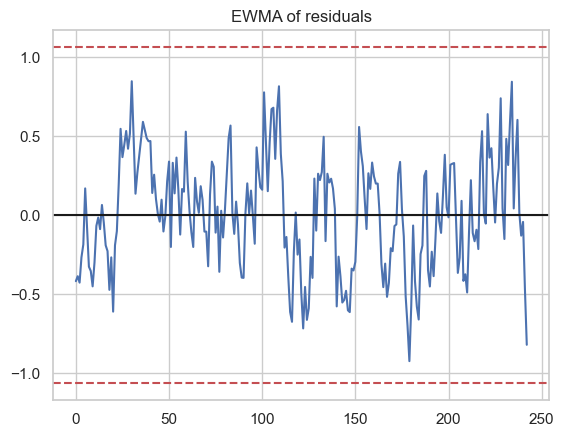

In [48]:
resid = gls.resid

lambda_ = 0.3
ewma = [resid.iloc[0]]
for e in resid.iloc[1:]:
    ewma.append(lambda_ * e + (1 - lambda_) * ewma[-1])

plt.plot(ewma); plt.axhline(0, c="k")
L = 3 * np.std(resid) * np.sqrt(lambda_/(2 - lambda_))
plt.axhline(L, c="r", ls="--"); plt.axhline(-L, c="r", ls="--")
plt.title("EWMA of residuals"); plt.show()


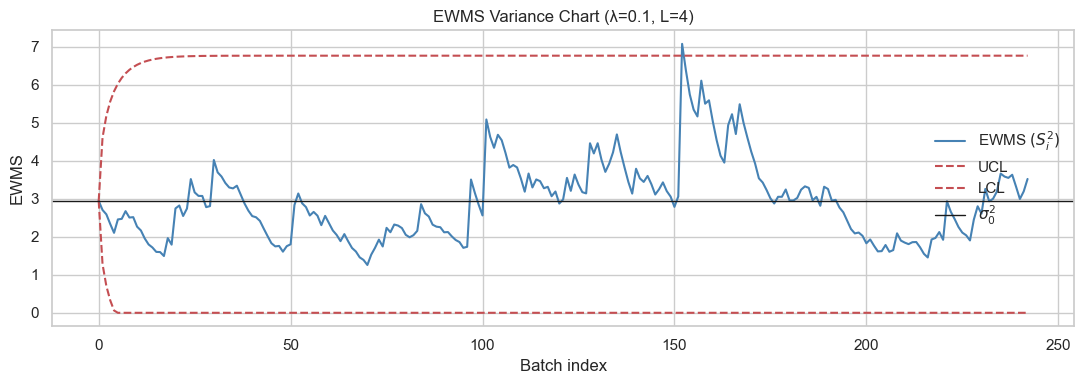

In [49]:
# 做標準化殘差 (純隨機成分)
standardized_resid = resid / np.sqrt(sigma_hat)
resid_sq = standardized_resid ** 2

lam, L = 0.1, 4
n = len(resid_sq)

# ---------- 中心線 ----------
sigma0_sq = resid_sq.mean()            # Phase-I 長期變異

# ---------- 計算 EWMS ----------
S = np.zeros(n)
S[0] = sigma0_sq                       # S₀²
for i in range(1, n):
    S[i] = lam*resid_sq.iloc[i] + (1-lam)*S[i-1]

# ---------- 管制界限 (EWMS 公式) ----------
k = np.arange(n)
sigma_S = sigma0_sq * np.sqrt( 2*lam/(2-lam) * (1 - (1-lam)**(2*k)) )
ucl = sigma0_sq + L * sigma_S
lcl = np.maximum(0, sigma0_sq - L * sigma_S)

# ---------- 繪圖 ----------
plt.figure(figsize=(11,4))
plt.plot(S, label="EWMS $(S_i^2)$", color="steelblue")
plt.plot(ucl, "r--", label="UCL"); plt.plot(lcl, "r--", label="LCL")
plt.axhline(sigma0_sq, color="k", lw=1, label=r"$\sigma_0^{2}$")
plt.title(f"EWMS Variance Chart (λ={lam}, L={L})")
plt.xlabel("Batch index"); plt.ylabel("EWMS")
plt.legend(frameon=False); plt.tight_layout(); plt.show()



# 考量路徑順序抓趨勢

In [66]:
df_drop = df_drop.loc[:, ~df_drop.T.duplicated()]
df_drop

,LOT,WAFER,OBSERVATION,T0001,T0002,T0003,T0004,T0005,T0006,T0007,...,T2729,T2730,T2734,T2736,T2737,T2740,LOT_MACHINE,process_step,weighted_step,log_u2
0,LOT1,1,14.5480,0,0,0,1,0,0,0,...,1,0,0,0,0,1,LOT1_0,523,660597,-1.741536
1,LOT1,2,14.6524,0,0,0,1,0,0,0,...,0,0,0,0,0,1,LOT1_0,521,658344,-2.315261
2,LOT1,3,14.4436,0,0,0,1,0,0,0,...,1,0,0,0,0,1,LOT1_0,521,658345,-1.296233
3,LOT1,4,15.0736,0,0,0,1,0,0,0,...,1,0,0,0,0,1,LOT1_0,521,658345,-4.470411
4,LOT1,5,14.9692,0,0,0,1,0,0,0,...,1,0,0,0,0,1,LOT1_0,521,658345,-11.927591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,LOT10,20,18.1084,0,0,1,0,0,0,0,...,0,0,1,0,0,1,LOT10_1,523,659643,0.610390
241,LOT10,21,18.9976,0,0,1,0,0,0,0,...,0,0,1,0,0,1,LOT10_1,525,661920,-1.519900
242,LOT10,22,19.6240,0,0,1,0,0,0,0,...,0,0,1,0,0,1,LOT10_1,523,659669,-3.681352
243,LOT10,23,16.4848,0,0,1,0,0,0,0,...,0,0,1,0,0,1,LOT10_1,523,659630,0.743682


In [67]:
df_drop["LOT_MACHINE"] = df_drop["LOT"].astype(str) + "_" + df_drop["T0456"].astype(str)


C:\Users\jason\AppData\Local\Temp\ipykernel_50396\982907245.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_drop["LOT_MACHINE"] = df_drop["LOT"].astype(str) + "_" + df_drop["T0456"].astype(str)


In [68]:
# route_cols 是你的全機台清單
route_cols_actual = list(set(route_cols) & set(df.columns))

T_cols = [c for c in df_drop.columns if c.startswith('T')]
# 再去做你剛剛那個計算
# 直接計算每片 wafer 有多少個機台參與
df_drop['process_step'] = df_drop[T_cols].sum(axis=1)

df_drop['process_step'] 


C:\Users\jason\AppData\Local\Temp\ipykernel_50396\4067924225.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_drop['process_step'] = df_drop[T_cols].sum(axis=1)


0      255
1      252
2      254
3      254
4      254
      ... 
240    239
241    241
242    237
243    238
244    238
Name: process_step, Length: 243, dtype: int64

In [69]:
T_cols = [c for c in df_drop.columns if c.startswith('T')]
T_cols_sorted = sorted(T_cols)
# 給順序性權重 (例如：第一道站權重為1、第二道為2...)
process_weight = {machine: i+1 for i, machine in enumerate(T_cols_sorted)}
process_weight_series = pd.Series(process_weight)
df_drop['weighted_step'] = df_drop[T_cols_sorted].mul(process_weight_series, axis=1).sum(axis=1)
df_drop['weighted_step']

C:\Users\jason\AppData\Local\Temp\ipykernel_50396\1407483131.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_drop['weighted_step'] = df_drop[T_cols_sorted].mul(process_weight_series, axis=1).sum(axis=1)


0      100015
1       98264
2       99785
3       99785
4       99784
        ...  
240     95578
241     96139
242     94306
243     95135
244     95124
Name: weighted_step, Length: 243, dtype: int64

# 最終model

In [70]:
df_drop['log_u2'] = np.log(resid**2)

C:\Users\jason\AppData\Local\Temp\ipykernel_50396\588764803.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_drop['log_u2'] = np.log(resid**2)


In [71]:
import statsmodels.formula.api as smf


md = smf.mixedlm("log_u2 ~ T0456 + weighted_step", 
                 data=df_drop, 
                 groups=df_drop["LOT"])
mdf = md.fit()
print(mdf.summary())


# σ² = exp(alpha0 + alpha1*T0456)
sigma_hat = np.exp(mdf.predict(df_drop))
gls = sm.GLS(df_drop["OBSERVATION"], m.model.exog, sigma=sigma_hat).fit()
print(gls.summary())

         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: log_u2   
No. Observations:  243     Method:             REML     
No. Groups:        10      Scale:              4.0196   
Min. group size:   23      Log-Likelihood:     -526.2025
Max. group size:   25      Converged:          Yes      
Mean group size:   24.3                                 
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      2.974    4.050  0.734 0.463 -4.963 10.911
T0456          0.747    0.311  2.402 0.016  0.138  1.356
weighted_step -0.000    0.000 -1.180 0.238 -0.000  0.000
Group Var      0.174    0.090                           

                            GLS Regression Results                            
Dep. Variable:            OBSERVATION   R-squared:                       0.776
Model:                            GLS   Adj. R-square

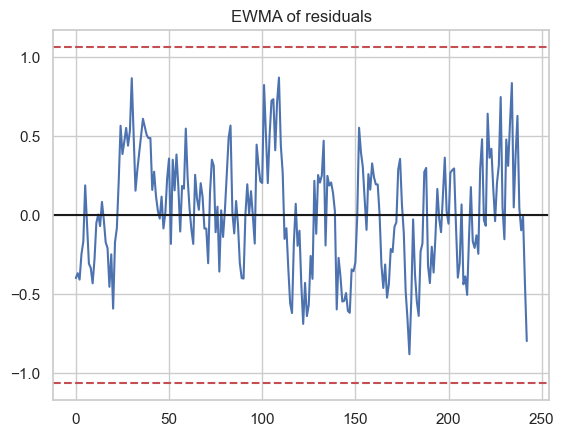

In [72]:
resid = gls.resid

lambda_ = 0.3
ewma = [resid.iloc[0]]
for e in resid.iloc[1:]:
    ewma.append(lambda_ * e + (1 - lambda_) * ewma[-1])

plt.plot(ewma); plt.axhline(0, c="k")
L = 3 * np.std(resid) * np.sqrt(lambda_/(2 - lambda_))
plt.axhline(L, c="r", ls="--"); plt.axhline(-L, c="r", ls="--")
plt.title("EWMA of residuals"); plt.show()


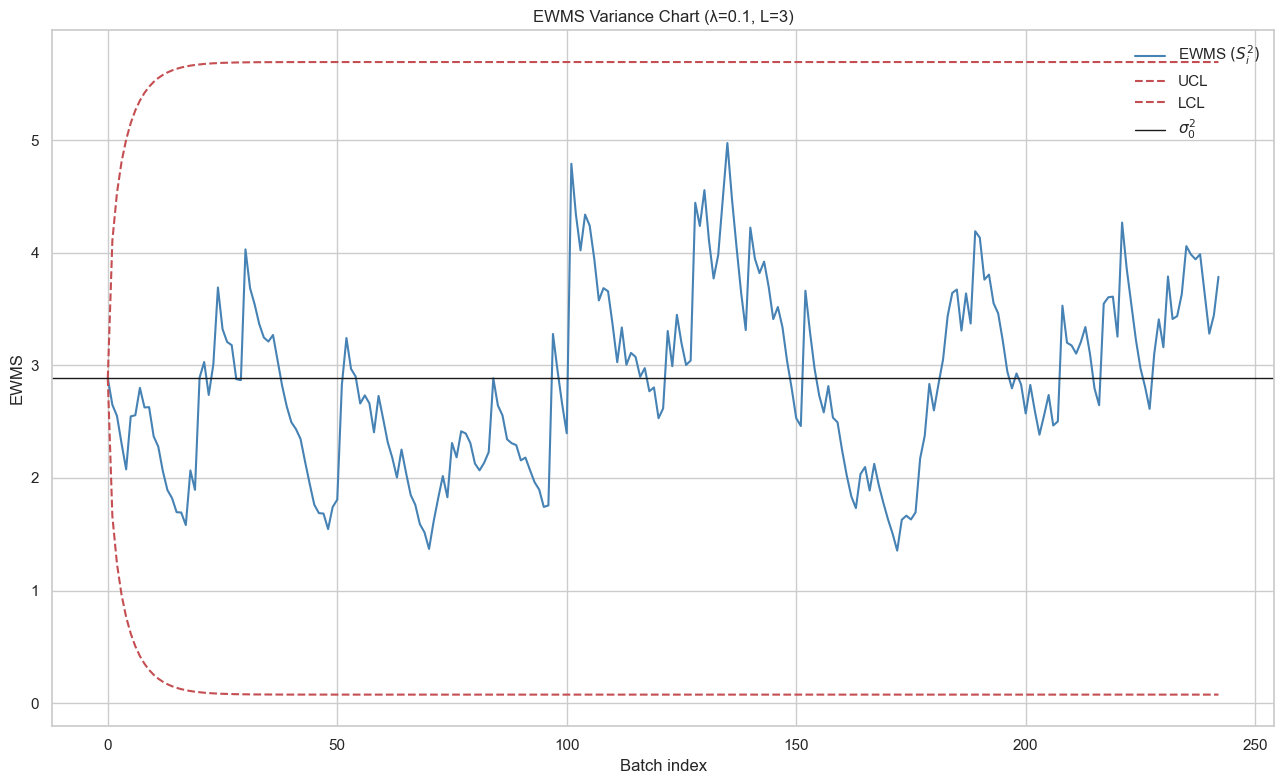

In [73]:
# 做標準化殘差 (純隨機成分)
standardized_resid = resid / np.sqrt(sigma_hat)
resid_sq = standardized_resid ** 2

lam, L = 0.1, 3
n = len(resid_sq)

# ---------- 中心線 ----------
sigma0_sq = resid_sq.mean()            # Phase-I 長期變異

# ---------- 計算 EWMS ----------
S = np.zeros(n)
S[0] = sigma0_sq                       # S₀²
for i in range(1, n):
    S[i] = lam*resid_sq.iloc[i] + (1-lam)*S[i-1]

# ---------- 管制界限 (EWMS 公式) ----------
k = np.arange(n)
sigma_S = sigma0_sq * np.sqrt( 2*lam/(2-lam) * (1 - (1-lam)**(2*k)) )
ucl = sigma0_sq + L * sigma_S
lcl = np.maximum(0, sigma0_sq - L * sigma_S)

# ---------- 繪圖 ----------
plt.figure(figsize=(13,8))
plt.plot(S, label="EWMS $(S_i^2)$", color="steelblue")
plt.plot(ucl, "r--", label="UCL"); plt.plot(lcl, "r--", label="LCL")
plt.axhline(sigma0_sq, color="k", lw=1, label=r"$\sigma_0^{2}$")
plt.title(f"EWMS Variance Chart (λ={lam}, L={L})")
plt.xlabel("Batch index"); plt.ylabel("EWMS")
plt.legend(frameon=False, loc='upper right'); plt.tight_layout(); plt.show()


# 選lot當作隨機效應的必要性

In [74]:
df_drop['log_u2'] = np.log(resid ** 2)
# 算每個 LOT 的平均與標準差
lot_summary = df.groupby('LOT')['log_u2'].agg(['mean', 'std', 'count']).reset_index()

print(lot_summary)

     LOT      mean       std  count
0   LOT1 -2.291797  2.640988     24
1  LOT10 -0.527953  1.802490     24
2   LOT2 -1.567084  1.476018     24
3   LOT3 -1.521501  1.661290     24
4   LOT4 -0.892843  0.903058     25
5   LOT5 -1.452365  2.554317     25
6   LOT6 -1.320758  2.120466     25
7   LOT7 -2.478267  2.218151     25
8   LOT8 -1.022122  1.904233     23
9   LOT9 -1.281065  1.808518     24


C:\Users\jason\AppData\Local\Temp\ipykernel_50396\2717509709.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_drop['log_u2'] = np.log(resid ** 2)


C:\Users\jason\AppData\Local\Temp\ipykernel_50396\3711012228.py:9: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) Arial.
  plt.tight_layout()


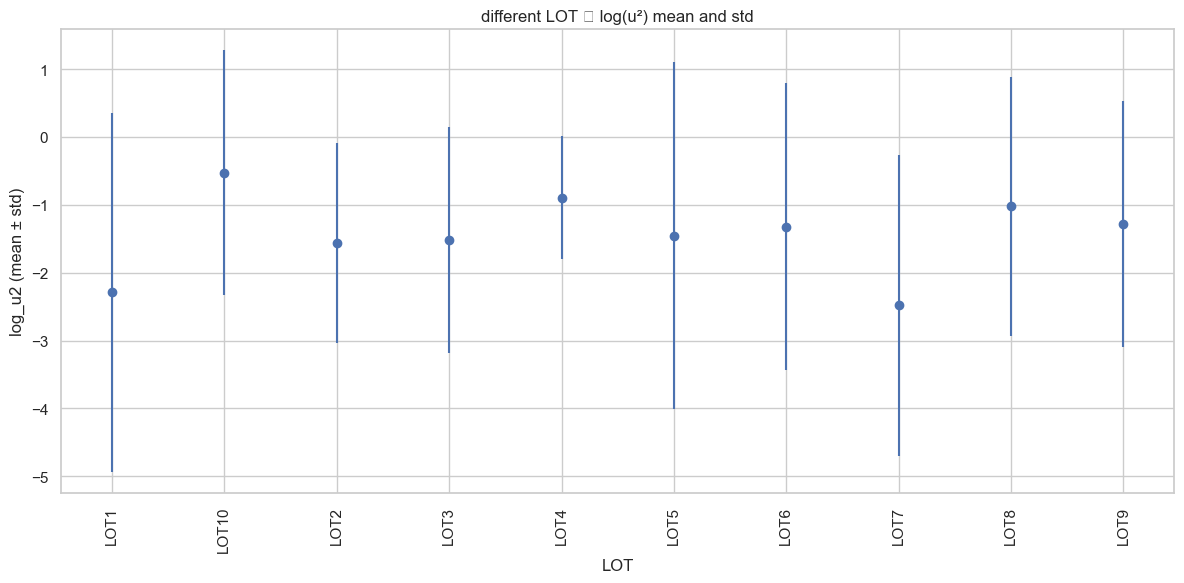

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.errorbar(lot_summary['LOT'], lot_summary['mean'], yerr=lot_summary['std'], fmt='o')
plt.xticks(rotation=90)
plt.xlabel("LOT")
plt.ylabel("log_u2 (mean ± std)")
plt.title("different LOT 間 log(u²) mean and std")
plt.tight_layout()
plt.show()


In [77]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ANOVA：看 LOT 對 log_u2 是否有顯著影響
model = smf.ols('log_u2 ~ C(LOT)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


             sum_sq     df         F    PR(>F)
C(LOT)     77.34034    9.0  2.210256  0.022207
Residual  905.89302  233.0       NaN       NaN


In [81]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# 新增字型設定：改成你電腦已經有的中文字型
matplotlib.rcParams['font.family'] = 'Microsoft JhengHei'  # 微軟正黑體
matplotlib.rcParams['axes.unicode_minus'] = False  # 避免負號顯示成方塊




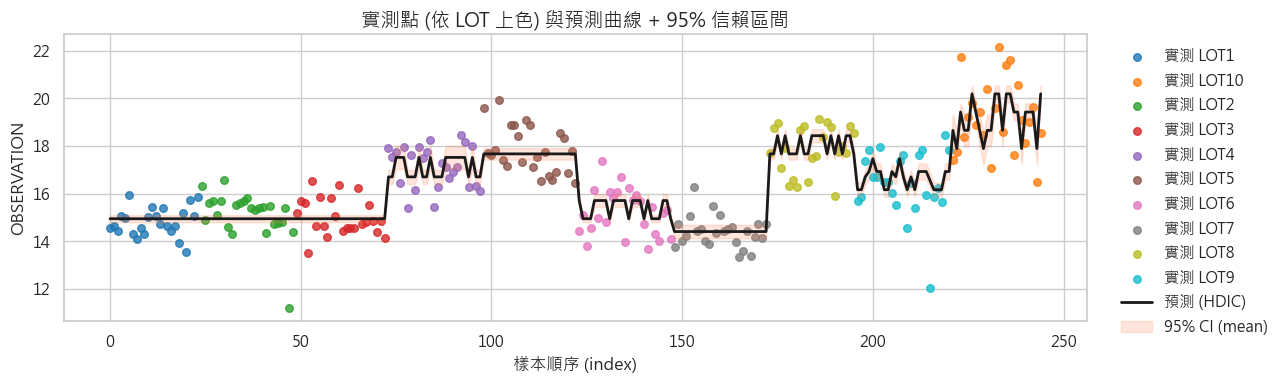

In [82]:
# 2. 取得預測值與 95% CI
pred = gls.get_prediction()
pframe = pred.summary_frame(alpha=0.05)   # columns: mean, mean_ci_lower, mean_ci_upper

# 3. 繪圖
plt.figure(figsize=(13,4))
palette = sns.color_palette("tab10", n_colors=df["LOT"].nunique())

# 實測散點 (按 LOT 上色)
for i, (lot, g) in enumerate(df.groupby("LOT")):
    plt.scatter(g.index, g["OBSERVATION"],
                label=f"實測 {lot}", s=30, alpha=0.8, color=palette[i])

# GLS 預測線
plt.plot(df_drop.index, pframe["mean"], color="k", linewidth=2.0, label="預測 (HDIC)")

# 95 % 信賴帶
plt.fill_between(df_drop.index, pframe["mean_ci_lower"], pframe["mean_ci_upper"],
                 color="coral", alpha=0.20, label="95% CI (mean)")

# 美化
plt.title("實測點 (依 LOT 上色) 與預測曲線 + 95% 信賴區間", fontsize=14)
plt.xlabel("樣本順序 (index)")
plt.ylabel("OBSERVATION")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()


# Appendix

<Figure size 800x400 with 0 Axes>

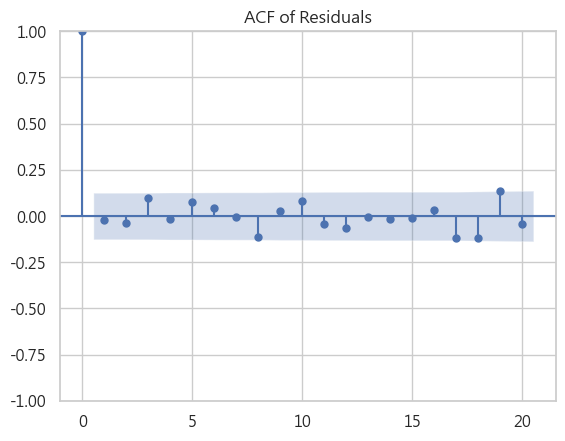

Durbin-Watson statistic: 2.026
     lb_stat  lb_pvalue
10  9.846871   0.454029


In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf

# --- 1. 畫 ACF 圖 ---
plt.figure(figsize=(8, 4))
plot_acf(resid, lags=20)
plt.title("ACF of Residuals")
plt.show()

# --- 2. Durbin-Watson 統計量 ---
dw_stat = durbin_watson(resid)
print(f"Durbin-Watson statistic: {dw_stat:.3f}")

# 判斷範圍: 2 = 無自相關, <2 趨向正相關, >2 趨向負相關

# --- 3. Ljung-Box test ---
lb_test = acorr_ljungbox(resid, lags=[10], return_df=True)
print(lb_test)


In [83]:
import pandas as pd

# 載入資料並檢查維度
df = pd.read_csv('new_wafer_data.csv')
print("原始資料維度：", df.shape)
print("欄位前十個：", list(df.columns[:10]))

# 移除不需欄位
df = df.drop(columns=['Unnamed: 0','LOT','WAFER'])
print("處理後欄位數：", len(df.columns), "（含目標欄位）")

# 檢查缺值
print("缺值檢查：", df.isnull().any().any())


原始資料維度： (245, 2744)
欄位前十個： ['Unnamed: 0', 'LOT', 'WAFER', 'OBSERVATION', 'T0001', 'T0002', 'T0003', 'T0004', 'T0005', 'T0006']
處理後欄位數： 2741 （含目標欄位）
缺值檢查： False


In [84]:
# 保留 Txxxx 欄位和目標欄位
features = [c for c in df.columns if c.startswith('T')]
target = 'OBSERVATION'

# 去除常數欄位和極低頻欄位
vars = df[features].var()
zero_vars = vars[vars == 0].index
df.drop(columns=zero_vars, inplace=True)
features = [c for c in df.columns if c.startswith('T')]

nonzero_count = (df[features] != 0).sum()
rare_feats = nonzero_count[nonzero_count < 5].index
df.drop(columns=rare_feats, inplace=True)
features = [c for c in df.columns if c.startswith('T')]

print("最終欄位數：", len(df.columns))


最終欄位數： 2595


In [85]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

# 定義基線特徵與目標
baseline_feats = ['T0456','T1370','T0404']
X_base = df[baseline_feats].values
y = df[target].values

# 標準化基線特徵
scaler_base = StandardScaler()
X_base_scaled = scaler_base.fit_transform(X_base)

# 5-fold 交叉驗證計算 MAE（使用 neg_mean_absolute_error 再取負號）
cv = KFold(n_splits=5, shuffle=True, random_state=0)
lr = LinearRegression()
mae_base = -cross_val_score(lr, X_base_scaled, y, cv=cv, scoring='neg_mean_absolute_error')
print(f"基線模型 MAE 平均值：{mae_base.mean():.4f}，標準差：{mae_base.std():.4f}")


基線模型 MAE 平均值：0.8094，標準差：0.0960


In [86]:
from sklearn.linear_model import Lasso, LassoCV
from sklearn.feature_selection import RFE, SequentialFeatureSelector

X_rest = df[[f for f in features if f not in baseline_feats]].values
# 標準化其餘特徵
scaler_rest = StandardScaler()
X_rest_scaled = scaler_rest.fit_transform(X_rest)

# LassoCV 自動尋找最佳 alpha
lasso_cv = LassoCV(cv=5, random_state=0, max_iter=10000)
lasso_cv.fit(X_rest_scaled, y)
print("LassoCV 最佳 alpha：", round(lasso_cv.alpha_, 4))

# 使用較小 alpha 以選出更多特徵 (此處取 0.1)
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_rest_scaled, y)
lasso_feats = [f for f, coef in zip([f for f in features if f not in baseline_feats], lasso.coef_) if coef != 0]
print(f"Lasso 選出 {len(lasso_feats)} 個特徵：", lasso_feats[:10], "…")

# RFE 範例：選取前 10 個特徵 (每次剔除500個以加速)
rfe = RFE(estimator=LinearRegression(), n_features_to_select=10, step=500)
rfe.fit(X_rest_scaled, y)
rfe_feats = [f for f, sel in zip([f for f in features if f not in baseline_feats], rfe.support_) if sel]
print("RFE 選出特徵（10個）：", rfe_feats)

# 前向選擇：選取 3 個最重要特徵（示範）
sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select=3, direction='forward',
                                cv=5, scoring='neg_mean_absolute_error', n_jobs=1)
sfs.fit(X_rest_scaled, y)
sfs_feats = [f for f, sel in zip([f for f in features if f not in baseline_feats], sfs.get_support()) if sel]
print("前向選擇選出 3 個特徵：", sfs_feats)


LassoCV 最佳 alpha： 1.2925
Lasso 選出 27 個特徵： ['T0063', 'T0364', 'T0374', 'T0447', 'T0449', 'T0450', 'T0453', 'T0510', 'T0536', 'T0572'] …
RFE 選出特徵（10個）： ['T0001', 'T0029', 'T0055', 'T0076', 'T0081', 'T0111', 'T1177', 'T1307', 'T1332', 'T2538']
前向選擇選出 3 個特徵： ['T1108', 'T1122', 'T2455']


In [88]:

from sklearn.preprocessing import StandardScaler

# 1. 基準特徵 (已計算，MAE ≈0.8094)

# 2. 基準 + Lasso 特徵 (共30特徵)
combo2_feats = baseline_feats + lasso_feats
X2 = df[combo2_feats].values
X2_scaled = StandardScaler().fit_transform(X2)
mae2 = -cross_val_score(lr, X2_scaled, y, cv=cv, scoring='neg_mean_absolute_error')
print(f"基準+Lasso ({len(combo2_feats)}特徵) MAE: {mae2.mean():.4f} ± {mae2.std():.4f}")

# 3. 基準 + RFE 特徵 (共13特徵)
combo3_feats = baseline_feats + rfe_feats
X3 = df[combo3_feats].values
X3_scaled = StandardScaler().fit_transform(X3)
mae3 = -cross_val_score(lr, X3_scaled, y, cv=cv, scoring='neg_mean_absolute_error')
print(f"基準+RFE ({len(combo3_feats)}特徵) MAE: {mae3.mean():.4f} ± {mae3.std():.4f}")

# 4. 基準 + 前向特徵 (共6特徵)
combo4_feats = baseline_feats + sfs_feats
X4 = df[combo4_feats].values
X4_scaled = StandardScaler().fit_transform(X4)
mae4 = -cross_val_score(lr, X4_scaled, y, cv=cv, scoring='neg_mean_absolute_error')
print(f"基準+Forward ({len(combo4_feats)}特徵) MAE: {mae4.mean():.4f} ± {mae4.std():.4f}")

# 5a. 只使用 Lasso 特徵
X5a = df[lasso_feats].values
X5a_scaled = StandardScaler().fit_transform(X5a)
mae5a = -cross_val_score(lr, X5a_scaled, y, cv=cv, scoring='neg_mean_absolute_error')
print(f"僅Lasso特徵 ({len(lasso_feats)}特徵) MAE: {mae5a.mean():.4f} ± {mae5a.std():.4f}")

# 5b. 只使用 RFE 特徵
X5b = df[rfe_feats].values
X5b_scaled = StandardScaler().fit_transform(X5b)
mae5b = -cross_val_score(lr, X5b_scaled, y, cv=cv, scoring='neg_mean_absolute_error')
print(f"僅RFE特徵 ({len(rfe_feats)}特徵) MAE: {mae5b.mean():.4f} ± {mae5b.std():.4f}")

# 5c. 只使用 Forward 特徵
X5c = df[sfs_feats].values
X5c_scaled = StandardScaler().fit_transform(X5c)
mae5c = -cross_val_score(lr, X5c_scaled, y, cv=cv, scoring='neg_mean_absolute_error')
print(f"僅Forward特徵 ({len(sfs_feats)}特徵) MAE: {mae5c.mean():.4f} ± {mae5c.std():.4f}")


基準+Lasso (30特徵) MAE: 0.7295 ± 0.0616
基準+RFE (13特徵) MAE: 0.8033 ± 0.1107
基準+Forward (6特徵) MAE: 0.8151 ± 0.1003
僅Lasso特徵 (27特徵) MAE: 0.7182 ± 0.0421
僅RFE特徵 (10特徵) MAE: 0.8482 ± 0.1280
僅Forward特徵 (3特徵) MAE: 0.9080 ± 0.1566


In [89]:
# 匯入套件
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score

# 讀取資料
df = pd.read_csv('new_wafer_data.csv')

# 建立目標變數：先計算 LOT 平均並求殘差平方的對數
df['LOT'] = df['LOT'].astype(str)
lot_mean = df.groupby('LOT')['OBSERVATION'].transform('mean')
df['res'] = df['OBSERVATION'] - lot_mean
df['log_var'] = np.log(df['res']**2)

# 特徵清理：挑選 TXXXX 欄位，剔除常數欄與低頻欄（以出現次數<5為準）
t_cols = [c for c in df.columns if c.startswith('T')]
# 常數欄位（全 0 或全 1）
constant_cols = [c for c in t_cols if df[c].std() == 0]
# 低頻欄位
low_freq_cols = [c for c in t_cols if df[c].sum() < 5]
# 最終候選特徵
features = [c for c in t_cols if c not in constant_cols + low_freq_cols]

# 準備資料集
X = df[features]
y = df['log_var']

# 特徵標準化（Lasso 需要）
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

# -----------------
# Lasso 特徵選擇
# -----------------
lasso = LassoCV(cv=5, random_state=0, max_iter=5000)
lasso.fit(X_scaled, y)
# 篩選出非零係數特徵
lasso_coefs = pd.Series(lasso.coef_, index=features)
lasso_selected = list(lasso_coefs[lasso_coefs != 0].index)
# 取絕對值前 10 大
lasso_top10 = lasso_coefs.abs().sort_values(ascending=False).iloc[:10]
lasso_vars = list(lasso_top10.index)
print("Lasso 選出的前10重要變數：", lasso_vars)

# -----------------
# RFE 特徵選擇
# -----------------
lr = LinearRegression()
rfe = RFE(lr, n_features_to_select=10, step=50)
rfe.fit(X, y)
rfe_selected = [feat for feat, sel in zip(features, rfe.support_) if sel]
print("RFE 選出的10個變數：", rfe_selected)

# -------------------------------
# 前向逐步篩選（Forward Selection）
# -------------------------------
# 基於相關性挑選候選特徵（加速計算）
corrs = X.corrwith(y).abs().sort_values(ascending=False)
top_corr = list(corrs.index[:100])
if 'T0456' not in top_corr:  # 確保 T0456 在候選中
    top_corr.append('T0456')
candidates = [f for f in top_corr]
selected = ['T0456']  # 強制包含T0456
kf = KFold(n_splits=5, shuffle=True, random_state=0)
def cv_mae(feats):
    maes = []
    for train_idx, test_idx in kf.split(X):
        model = LinearRegression().fit(X.iloc[train_idx][feats], y.iloc[train_idx])
        pred = model.predict(X.iloc[test_idx][feats])
        maes.append(mean_absolute_error(y.iloc[test_idx], pred))
    return np.mean(maes)

current_mae = cv_mae(selected)
for i in range(9):
    best_feat = None
    best_mae = current_mae
    for feat in candidates:
        if feat in selected: continue
        mae = cv_mae(selected + [feat])
        if mae < best_mae:
            best_mae = mae
            best_feat = feat
    if best_feat is None:
        break
    selected.append(best_feat)
    current_mae = best_mae
    print(f"Step {i+1}: 加入 {best_feat}, MAE = {best_mae:.4f}")

print("前向逐步選出的變數：", selected)

# 為列出至少10個變數，若不足可再加上相關度高的特徵（此處示例補到10個）
if len(selected) < 10:
    for feat in corrs.index:
        if feat not in selected:
            selected.append(feat)
        if len(selected) >= 10:
            break
forward_vars = selected[:10]
print("前向逐步列出的前10個變數：", forward_vars)

# -----------------
# 模型評估 (5-fold CV MAE)
# -----------------
sets = {
    'Lasso': lasso_vars,
    'RFE': rfe_selected + (['T0456'] if 'T0456' not in rfe_selected else []),
    'Forward': forward_vars
}
for name, feats in sets.items():
    feats = list(set(feats))  # 確保唯一
    # 計算 CV MAE
    maes = []
    for train_idx, test_idx in kf.split(X):
        model = LinearRegression().fit(X.iloc[train_idx][feats], y.iloc[train_idx])
        pred = model.predict(X.iloc[test_idx][feats])
        maes.append(mean_absolute_error(y.iloc[test_idx], pred))
    print(f"{name} 模型使用 {len(feats)} 個特徵, 平均 CV MAE = {np.mean(maes):.4f}")

# 推薦 Lasso 組合的訓練資料 R^2
best_feats = lasso_vars
model = LinearRegression().fit(X[best_feats], y)
r2 = r2_score(y, model.predict(X[best_feats]))
print(f"Lasso 組合的訓練 R^2 = {r2:.3f}")


Lasso 選出的前10重要變數： ['T1667', 'T2368', 'T1316', 'T1247', 'T2568', 'T2381', 'T1318', 'T0926', 'T0456', 'T1309']
RFE 選出的10個變數： ['T0300', 'T0351', 'T0772', 'T0880', 'T0994', 'T1098', 'T1797', 'T2339', 'T2455', 'T2496']
Step 1: 加入 T2661, MAE = 1.6184
Step 2: 加入 T0896, MAE = 1.6097
Step 3: 加入 T1325, MAE = 1.6070
Step 4: 加入 T1667, MAE = 1.6061
Step 5: 加入 T0813, MAE = 1.6052
前向逐步選出的變數： ['T0456', 'T2661', 'T0896', 'T1325', 'T1667', 'T0813']
前向逐步列出的前10個變數： ['T0456', 'T2661', 'T0896', 'T1325', 'T1667', 'T0813', 'T1316', 'T1333', 'T0063', 'T0440']
Lasso 模型使用 10 個特徵, 平均 CV MAE = 1.6102
RFE 模型使用 11 個特徵, 平均 CV MAE = 1.6898
Forward 模型使用 10 個特徵, 平均 CV MAE = 1.6416
Lasso 組合的訓練 R^2 = 0.155


In [ ]:
import pandas as pd
import numpy as np

# 讀取資料
df = pd.read_csv("new_wafer_data.csv")
df = df.drop(columns=['Unnamed: 0', 'LOT', 'WAFER'])

# 假設 OBSERVATION 是 target，其他變數是 feature
X = df.drop(columns=["OBSERVATION"]).values
y = df["OBSERVATION"].values

# 簡單標準化 (你也可以改用更好的 scaler)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)




In [93]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ResNet Block 定義
class ResidualBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, input_dim)
        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(input_dim)
    
    def forward(self, x):
        identity = x
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        return out

# ResNet 模型
class ResNetRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_blocks=3):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.blocks = nn.Sequential(*[ResidualBlock(hidden_dim, hidden_dim) for _ in range(num_blocks)])
        self.output_layer = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.input_layer(x))
        x = self.blocks(x)
        x = self.output_layer(x)
        return x


In [116]:
# 轉 tensor
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1).to(device)

# 建立模型
model = ResNetRegressor(input_dim=X_tensor.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# 訓練
for epoch in range(200):
    model.train()
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = loss_fn(output, y_tensor)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 20, Loss: 11.4434
Epoch 40, Loss: 3.0990
Epoch 60, Loss: 1.1322
Epoch 80, Loss: 0.8303
Epoch 100, Loss: 0.7499
Epoch 120, Loss: 0.7041
Epoch 140, Loss: 0.6677
Epoch 160, Loss: 0.6362
Epoch 180, Loss: 0.6087
Epoch 200, Loss: 0.5832


In [120]:
from sklearn.base import BaseEstimator, RegressorMixin

class TorchRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def fit(self, X, y):
        # 這裡不用做事，騙過 sklearn 而已
        return self

    def predict(self, X):
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        self.model.eval()
        with torch.no_grad():
            preds = self.model(X_tensor).cpu().numpy().flatten()
        return preds


In [121]:
from sklearn.inspection import permutation_importance

# 建立包裝好的 estimator
wrapped_model = TorchRegressorWrapper(model, device)

# 做 permutation importance
result = permutation_importance(wrapped_model, X_scaled, y, n_repeats=20, random_state=42)

# 排序顯示
importances = result.importances_mean
indices = np.argsort(importances)[::-1]

for i in indices:
    print(f"Feature {i}: Importance = {importances[i]:.4f}")


Feature 1249: Importance = 0.0038
Feature 1201: Importance = 0.0037
Feature 1308: Importance = 0.0034
Feature 1578: Importance = 0.0029
Feature 446: Importance = 0.0023
Feature 1307: Importance = 0.0023
Feature 1246: Importance = 0.0022
Feature 1227: Importance = 0.0022
Feature 872: Importance = 0.0019
Feature 1240: Importance = 0.0015
Feature 1193: Importance = 0.0014
Feature 1202: Importance = 0.0012
Feature 871: Importance = 0.0011
Feature 1312: Importance = 0.0010
Feature 437: Importance = 0.0010
Feature 445: Importance = 0.0010
Feature 1229: Importance = 0.0009
Feature 1192: Importance = 0.0009
Feature 1230: Importance = 0.0009
Feature 1786: Importance = 0.0009
Feature 438: Importance = 0.0009
Feature 1243: Importance = 0.0008
Feature 673: Importance = 0.0008
Feature 1594: Importance = 0.0008
Feature 440: Importance = 0.0008
Feature 1331: Importance = 0.0007
Feature 535: Importance = 0.0007
Feature 867: Importance = 0.0007
Feature 1311: Importance = 0.0007
Feature 1111: Importance

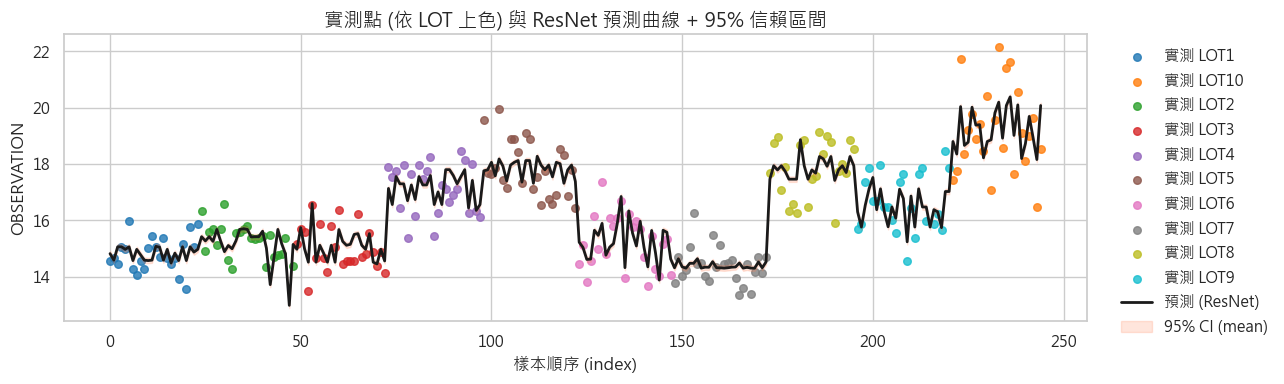

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 先用 ResNet 預測整個 X
model.eval()
with torch.no_grad():
    pred_resnet = model(X_tensor).cpu().numpy().flatten()

# 簡單估計標準誤 (暫時先用殘差標準差 / sqrt(n) 當作 mean estimate 的SE)
residuals = pred_resnet - y
se_residual = np.std(residuals)
se_mean = se_residual / np.sqrt(len(y))

# 95% CI (先簡單做全域常數誤差帶)
ci_upper = pred_resnet + 1.96 * se_mean
ci_lower = pred_resnet - 1.96 * se_mean

# 畫圖
plt.figure(figsize=(13,4))
palette = sns.color_palette("tab10", n_colors=df_drop["LOT"].nunique())

# 實測散點 (依 LOT 上色)
for i, (lot, g) in enumerate(df_drop.groupby("LOT")):
    plt.scatter(g.index, g["OBSERVATION"],
                label=f"實測 {lot}", s=30, alpha=0.8, color=palette[i])

# ResNet 預測線
plt.plot(df.index, pred_resnet, color="k", linewidth=2.0, label="預測 (ResNet)")

# 95% CI (mean)
plt.fill_between(df.index, ci_lower, ci_upper,
                 color="coral", alpha=0.20, label="95% CI (mean)")

# 美化
plt.title("實測點 (依 LOT 上色) 與 ResNet 預測曲線 + 95% 信賴區間", fontsize=14)
plt.xlabel("樣本順序 (index)")
plt.ylabel("OBSERVATION")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()


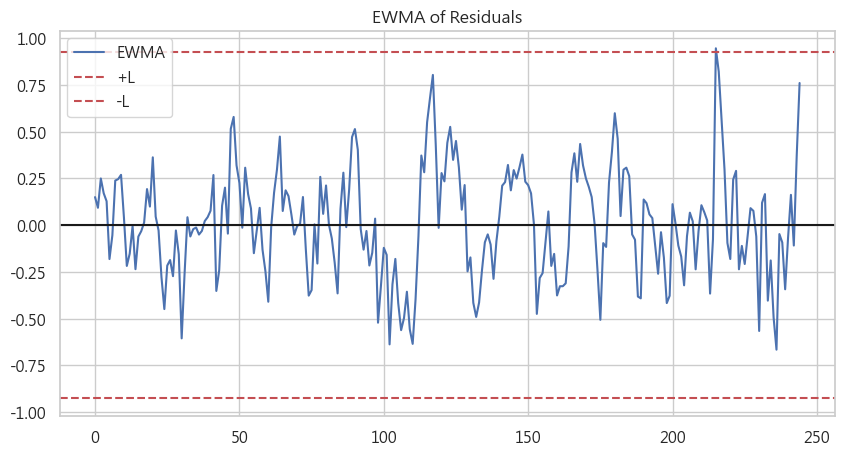

In [103]:
# 計算殘差
model.eval()
with torch.no_grad():
    pred = model(X_tensor).cpu().numpy().flatten()
    y_true = y_tensor.cpu().numpy().flatten()
    residuals = pred - y_true

# 殘差 EWMA 檢查
lambda_ = 0.3
ewma = np.zeros_like(residuals)
ewma[0] = residuals[0]
for i in range(1, len(residuals)):
    ewma[i] = lambda_ * residuals[i] + (1 - lambda_) * ewma[i-1]

L = 3 * np.std(residuals) * np.sqrt(lambda_/(2 - lambda_))

plt.figure(figsize=(10,5))
plt.plot(ewma, label="EWMA")
plt.axhline(0, c="k")
plt.axhline(L, c="r", ls="--", label="+L")
plt.axhline(-L, c="r", ls="--", label="-L")
plt.title("EWMA of Residuals")
plt.legend()
plt.show()

In [107]:
df['log_u2'] = np.log(residuals**2)

X_var = df.drop(columns=["OBSERVATION", "log_u2"]).values
y_var = df['log_u2'].values

# 標準化 X (可以共用前面的 scaler)
X_var_scaled = scaler.transform(X_var)

# 轉 tensor
X_var_tensor = torch.tensor(X_var_scaled, dtype=torch.float32).to(device)
y_var_tensor = torch.tensor(y_var, dtype=torch.float32).view(-1,1).to(device)

class VarianceModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x  # 輸出 log(sigma^2)


In [108]:
var_model = VarianceModel(input_dim=X_var.shape[1]).to(device)
optimizer_var = torch.optim.Adam(var_model.parameters(), lr=1e-3)
loss_fn_var = nn.MSELoss()

for epoch in range(300):
    var_model.train()
    optimizer_var.zero_grad()
    output = var_model(X_var_tensor)
    loss = loss_fn_var(output, y_var_tensor)
    loss.backward()
    optimizer_var.step()
    
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 50, Loss: 4.4138
Epoch 100, Loss: 3.0271
Epoch 150, Loss: 2.7662
Epoch 200, Loss: 2.5218
Epoch 250, Loss: 2.2658
Epoch 300, Loss: 2.0690


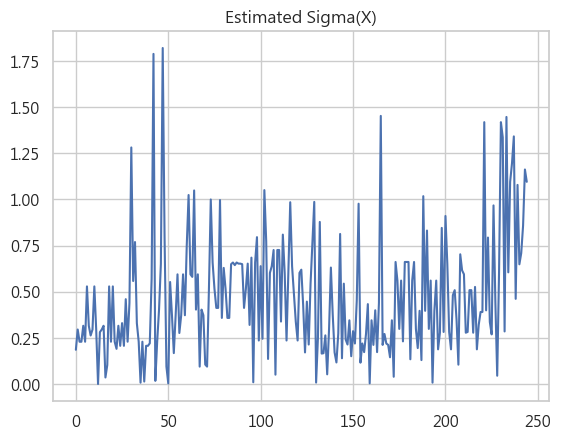

In [109]:
var_model.eval()
with torch.no_grad():
    log_sigma2_pred = var_model(X_var_tensor).cpu().numpy().flatten()
    sigma_pred = np.sqrt(np.exp(log_sigma2_pred))
    
plt.plot(sigma_pred)
plt.title("Estimated Sigma(X)")
plt.show()


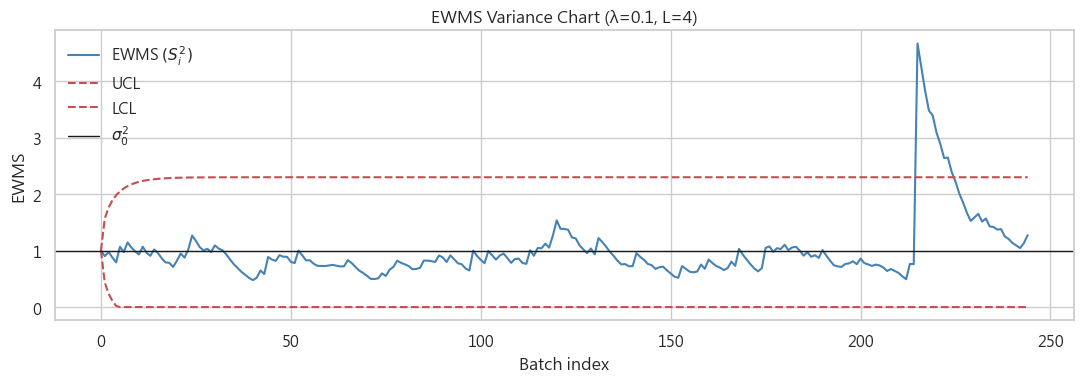

In [112]:
# 做標準化殘差 (純隨機成分)
standardized_resid = residuals / np.sqrt(sigma_pred)
resid_sq = standardized_resid ** 2

lam, L = 0.1, 4
n = len(resid_sq)

# ---------- 中心線 ----------
sigma0_sq = resid_sq.mean()  # Phase-I 長期變異

# ---------- 計算 EWMS ----------
S = np.zeros(n)
S[0] = sigma0_sq
for i in range(1, n):
    S[i] = lam * resid_sq[i] + (1 - lam) * S[i-1]

# ---------- 管制界限 (EWMS 公式) ----------
k = np.arange(n)
sigma_S = sigma0_sq * np.sqrt(2 * lam / (2 - lam) * (1 - (1 - lam) ** (2 * k)))
ucl = sigma0_sq + L * sigma_S
lcl = np.maximum(0, sigma0_sq - L * sigma_S)

# ---------- 繪圖 ----------
plt.figure(figsize=(11, 4))
plt.plot(S, label="EWMS $(S_i^2)$", color="steelblue")
plt.plot(ucl, "r--", label="UCL")
plt.plot(lcl, "r--", label="LCL")
plt.axhline(sigma0_sq, color="k", lw=1, label=r"$\sigma_0^{2}$")
plt.title(f"EWMS Variance Chart (λ={lam}, L={L})")
plt.xlabel("Batch index")
plt.ylabel("EWMS")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
